# IT5006 - EDA starter
## SmartCommerce Data Exploration

**Duration:** ~60 minutes  
**Prerequisites:** Lab 1.0 (Python/PyTorch Refresher)  
**Environment:** Google Colab (recommended) or local Jupyter

---

### 🎯 Learning Objectives

This mini lab is for you to:

1. Load and understand the **Olist e-commerce dataset** schema
2. **Merge multiple tables** using relational keys (order_id, customer_id, product_id)
3. Compute foundational **business KPIs** (Revenue, AOV, Repeat Rate, On-Time Delivery)
4. Create basic **visualizations** to understand data distributions
5. Document the data assets available for downstream analytics

---

### 📊 About the Dataset

**Olist** is a Brazilian e-commerce platform. The dataset contains ~100K orders from 2016-2018 across 9 interconnected tables:

| Table | Description | Key Columns |
|-------|-------------|-------------|
| `orders` | Order metadata & timestamps | order_id, customer_id, status, timestamps |
| `order_items` | Line items per order | order_id, product_id, price, freight |
| `customers` | Customer location | customer_id, city, state |
| `products` | Product catalog | product_id, category, dimensions |
| `sellers` | Seller location | seller_id, city, state |
| `payments` | Payment details | order_id, payment_type, value |
| `reviews` | Customer feedback | order_id, score, comment |
| `geolocation` | Zip code coordinates | zip_code, lat, lng |
| `category_translation` | Portuguese → English | category names |

> 💡 **SmartCommerce** is our fictional brand name for this e-commerce case study throughout the course.


---

## 1. Environment Setup & Data Loading


In [1]:
# Running locally from the repo — no Google Drive mount needed.
# (In Colab instead: `from google.colab import drive; drive.mount('/content/drive')`)

In [2]:
# Install dependencies (uncomment if running in Colab)
# !pip install -q pandas numpy matplotlib seaborn plotly

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


pandas: 2.3.3
numpy: 2.0.2


In [3]:
# === DATA PATH CONFIGURATION ===
DATA_DIR = "../Olist_data"   # CSVs at the repo root; this notebook runs from notebooks/

# Verify data directory exists
if os.path.exists(DATA_DIR):
    print(f"✅ Data directory found: {DATA_DIR}")
    print(f"   Files: {sorted(os.listdir(DATA_DIR))}")
else:
    print(f"❌ Data directory not found: {DATA_DIR}")
    print("   Update DATA_DIR to point to your Olist CSV folder")

✅ Data directory found: ../Olist_data
   Files: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [4]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data
olist = load_olist_data(DATA_DIR)

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols


Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols


Loaded reviews: 99,224 rows × 7 cols


Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


---

## 2. Schema Exploration

Let's understand each table's structure and relationships.


In [5]:
# Quick schema overview
def schema_summary(data_dict):
    """Generate a summary of all tables."""
    summary = []
    for name, df in data_dict.items():
        summary.append({
            'Table': name,
            'Rows': f"{df.shape[0]:,}",
            'Columns': df.shape[1],
            'Memory (MB)': f"{df.memory_usage(deep=True).sum() / 1e6:.2f}",
            'Columns List': ', '.join(df.columns)
        })
    return pd.DataFrame(summary)

pd.set_option('display.max_colwidth', None)

schema_summary(olist)

,Table,Rows,Columns,Memory (MB),Columns List
0,orders,"99,441",8,28.24,"order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date"
1,order_items,"112,650",7,33.68,"order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value"
2,customers,"99,441",5,31.06,"customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state"
3,products,"32,951",9,7.12,"product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
4,sellers,"3,095",4,0.69,"seller_id, seller_zip_code_prefix, seller_city, seller_state"
5,payments,"103,886",5,18.68,"order_id, payment_sequential, payment_type, payment_installments, payment_value"
6,reviews,"99,224",7,31.33,"review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp"
7,geolocation,"1,000,163",5,152.26,"geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state"
8,category_translation,71,2,0.01,"product_category_name, product_category_name_english"


### 2.1 Orders Table (Core Transaction Log)


In [6]:
# Orders - the central fact table
orders = olist['orders']
print("ORDERS TABLE")
print("=" * 50)
print(f"Shape: {orders.shape}")
print(f"\nColumn types:\n{orders.dtypes}")
print(f"\nOrder status distribution:\n{orders['order_status'].value_counts()}")
orders.head(3)

ORDERS TABLE
Shape: (99441, 8)

Column types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


### 📝Order Table Overiew

Orders dataset is the main order transaction table. Each row represents one customer order, identified by a unqiue `olist['order_id']`.

The table contains **99,441** orders and 8 columns.

The `olist['customer_id']` column connects each order to the customers table, while order_status describes the current or final stage of the order.

The important to note that `olist['customer_id']` is different for each order, so it cannot be used to identify the same customer across multiple orders. Therefore, we use `olist['customer_unique_id']` from the customers table for customer-level analysis.

1. `olist['order_purchase_timestamp']` When the customer placed the order
2. `olist['order_approved_at']` When the payment was approved
3. `olist['order_delivered_carrier_date']` When the order was passed to the delivery company
4. `olist['order_delivered_customer_date']` When the customer received the order
5. `olist['order_estimated_delivery_date']` The expected delivery date

Approximately **97%** [96478 (delivered) / 99441 (total orders) ] of the orders were successfully delivered.

The remaining records include shipped, cancelled, unavailable, invoiced, processing, created and approved orders.

Most orders in the dataset are completed. Some missing delivery dates may be normal for cancelled orders or orders that were not delivered yet. So, we should check the `olist['order_status']` before deciding that a missing timestamp is a data problem.

### 2.2 Order Items Table (Line-Level Details)


In [7]:
# Order Items - contains price and freight
order_items = olist['order_items']
print("ORDER ITEMS TABLE")
print("=" * 50)
print(f"Shape: {order_items.shape}")
print(f"\nPrice statistics:")
print(order_items[['price', 'freight_value']].describe())
order_items.head(3)

ORDER ITEMS TABLE
Shape: (112650, 7)

Price statistics:
          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
max     6735.00         409.68


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87


9803
orders with more than 1 item: 9.94%

88863
orders with only 1 item:90.06%

0
orders with more than zero item:0.00%


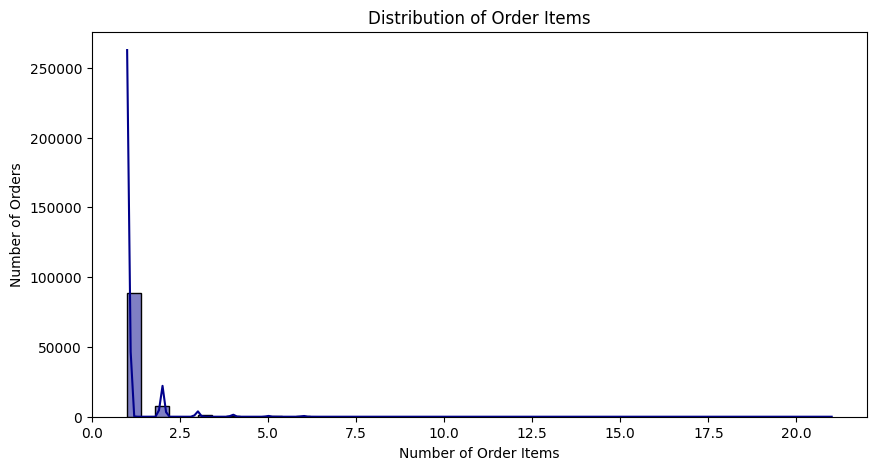

In [8]:
# determine how many orders have more than 1 order_ids
orders_by_count = order_items['order_id'].value_counts()
print(orders_by_count[orders_by_count > 1].count())
percentage = (orders_by_count[orders_by_count > 1].count() / orders_by_count.count()) * 100
print(f"orders with more than 1 item: {percentage:.2f}%")
print()

print(orders_by_count[orders_by_count == 1].count())
percentage = (orders_by_count[orders_by_count == 1].count() / orders_by_count.count()) * 100
print(f"orders with only 1 item:{percentage:.2f}%")
print()

print(orders_by_count[orders_by_count == 0].count())
percentage = (orders_by_count[orders_by_count == 0].count() / orders_by_count.count()) * 100
print(f"orders with more than zero item:{percentage:.2f}%")

# plot graph to represent above code
plt.figure(figsize=(10, 5))
sns.histplot(
    orders_by_count,
    bins=50,
    kde=True,
    color='darkblue'
)
plt.title('Distribution of Order Items')
plt.xlabel('Number of Order Items')
plt.ylabel('Number of Orders')
plt.show()

### 📝Order Items Table Overview

The **order_items** table provides line - level information about the products included in each other.

It contains **112,650** rows and seven variables.The table also contains the item price and freight value. Both columns have **112,650** valid observations, indicating that there are no missing values in these two columns.

Each row reprsents one item which an order, therefore, the same `olist['order_id']` may appear multiple times when a customer purchases more then one item.

The combination of `olist['order_id']` and `olist['order_item_id']` can be used to identify each individual line item.

The `olist['shipping_limit_date']` column records the deadline by which the seller was expected to transfer the item for shipment. It should not be confused with the actual carrier or customer delivery dates found in the orders table.


The average item price is **R\$120.65**, while the median price is **R$74.99**. Since the average is much higher than the median, this shows that there are some high-priced items pulling the average up. The item prices range from **R\$0.85** to **R\$6,735.00**.

The average freight value is **19.99** and the median is **16.26**. The freight cost ranges from **0.00** to **409.68**. Some orders may have free delivery, while a few orders have much higher delivery costs.

For analysis, should group the item prices by order_id first, because one order can contain more than one item.

### 2.3 Products Table (Catalog)


In [9]:
# Products with category translation
products = olist['products'].merge(
    olist['category_translation'],
    on='product_category_name',
    how='left'
)

# count how many products have no name before merging
product_no_name_count = products['product_category_name'].isnull().sum()
print(f"Products with no name before merging: {product_no_name_count}")

# count how many products have no name after merging
product_no_name_english_count = products['product_category_name_english'].isnull().sum()
print(f"Products with no name after merging: {product_no_name_english_count}")

# no of products with no english equivalent translation to original portuguese name
print(f"Products with no english equivalent translation: {product_no_name_english_count - product_no_name_count}")

# replace products with NA or null category names after merging
products['product_category_name_english'] = products['product_category_name_english'].fillna('Unknown')

print()
print("PRODUCTS TABLE (with English categories)")
print("=" * 50)
print(f"Shape: {products.shape}")
print(f"\nTop 10 categories:")
print(products['product_category_name_english'].value_counts().head(10))
print(f"\nUnknown Product:{(products['product_category_name_english'] == 'Unknown').sum()}")
products.head(3)

Products with no name before merging: 610
Products with no name after merging: 623
Products with no english equivalent translation: 13

PRODUCTS TABLE (with English categories)
Shape: (32951, 10)

Top 10 categories:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64

Unknown Product:623


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure


### 📝Products Table Overview

The products table has 32,951 records, and each row represents one product. It contains information such as the product category, weight, size, number of photos, and the length of the product name and description.

This table was created by joining `olist['products']` with `olist['category_translation']`. Both tables have the `product_category_name` column, so this column was used to match them. The original category names are in Portuguese, while the translation table provides their English names. A left join was used so that all products from the original products table were kept.

Some products did not have a category, while some categories could not be found in the translation table. Their English category names were shown as `NaN`, so they were replaced with `Unknown`. I found 623 products under the `Unknown` category.

The category with the most products is `bed_bath_table`, with 3,029 products. This is followed by `sports_leisure`, `furniture_decor`, `health_beauty` and `housewares`.

For later analysis, Need to take note that these numbers only show how many products are listed in each category. They do not show which categories had the highest sales. To analyse sales by category, the products table needs to be joined with the order items table. The product weight and size may also be useful when studying freight costs or delivery performance.


### 2.4 Customers Table (Geography)


In [10]:
# Customers
customers = olist['customers']
print("CUSTOMERS TABLE")
print("=" * 50)
print(f"Shape: {customers.shape}")
print(f"Unique customers: {customers['customer_unique_id'].nunique():,}")
print(f"\nTop 10 states:")
print(customers['customer_state'].value_counts().head(10))
customers.head(3)

CUSTOMERS TABLE
Shape: (99441, 5)
Unique customers: 96,096

Top 10 states:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


max no. of orders for a customer: 17
no of customers with at least one order: 2997
no of customers with only one order: 93099
no of customers with no orders: 0


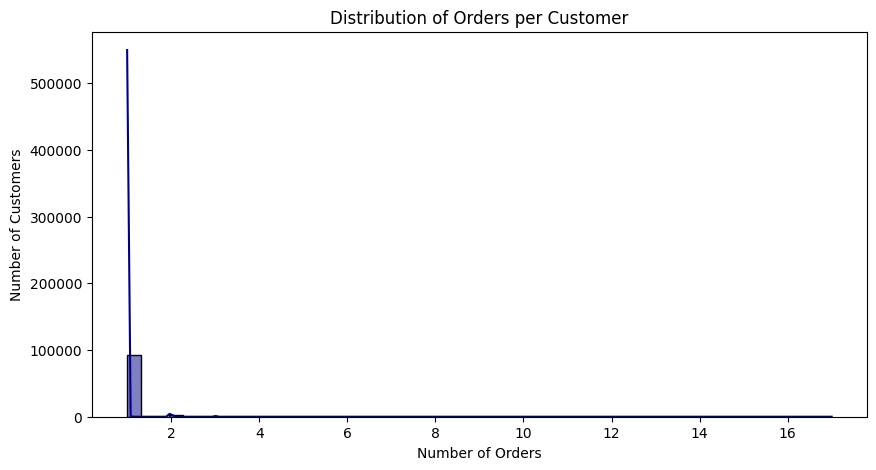

In [11]:
orders_per_customer = customers.merge(
    olist['orders'][['customer_id', 'order_id']],
    on='customer_id'
).groupby('customer_unique_id')['order_id'].nunique()

# print max number of orders for a customer
print(f"max no. of orders for a customer: {orders_per_customer.max()}")

# print number of customers with at least one order, only 1 order and no orders
print(f"no of customers with at least one order: {orders_per_customer[orders_per_customer > 1].count()}")
print(f"no of customers with only one order: {orders_per_customer[orders_per_customer == 1].count()}")
print(f"no of customers with no orders: {orders_per_customer[orders_per_customer == 0].count()}")

# plot a graph based on above code
plt.figure(figsize=(10, 5))
sns.histplot(
    orders_per_customer,
    bins=50,
    kde=True,
    color='darkblue'
)
plt.title('Distribution of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

### 📝Customers Table Overview

The `olist['customers']` table has 99,441 rows and five columns. It contains customer IDs and location information, including zip code prefix, city and state.

There are two customer IDs in this table. `olist['customers']['customer_id']` is created for each order, while `olist['customers']['customer_unique_id']` represents the actual customer. Therefore, the same customer may have different `customer_id` values when placing multiple orders, but the `customer_unique_id` remains the same.

**Take note:**

* Use `customer_id` when joining `olist['orders']` and `olist['customers']`.
* Use `customer_unique_id` when counting actual customers or finding repeat purchases.

There are 99,441 customer records but only 96,096 unique customers. By using `olist['customers']['customer_unique_id'].value_counts()`, I found that 2,997 customers appeared more than once. The largest value from `orders_per_customer.max()` is 17, meaning that one customer appeared 17 times in the dataset.

Most customer records are from São Paulo. SP has 41,746 records, followed by RJ with 12,852 and MG with 11,635. Together, these three states account for around 67% of the records. However, `olist['customers']['customer_state'].value_counts()` counts customer records rather than unique customers. Since repeat customers can have multiple `olist['customer_id']` records, the same actual customer may be counted more than once.

For later analysis, the customer location can be used to compare order volume, freight value and delivery time across different states. `olist['customers']['customer_zip_code_prefix']` can also be joined with `olist['geolocation']['geolocation_zip_code_prefix']` to obtain location coordinates. However, the Geolocation table should be cleaned first because the same zip code may appear multiple times.


### 2.5 Reviews Table (Customer Feedback)


In [12]:
# Reviews
reviews = olist['reviews']
print("REVIEWS TABLE")
print("=" * 50)
print(f"Shape: {reviews.shape}")
print(f"\nReview score distribution:")
print(reviews['review_score'].value_counts().sort_index())
print(f"\nReviews with comments: {reviews['review_comment_message'].notna().sum():,} ({reviews['review_comment_message'].notna().mean():.1%})")
reviews.head(3)

REVIEWS TABLE
Shape: (99224, 7)

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Reviews with comments: 40,977 (41.3%)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


### 📝Reviews Table Overview

The `olist['reviews']` table has 99,224 rows and seven columns. It contains the review score, comment, review date and the `order_id` linked to each review.

The most common score is 5, with 57,328 reviews. Around 77% of the reviews received either 4 or 5 stars, showing that most customer feedback was positive. However, 14,575 reviews received only 1 or 2 stars, which may be useful for studying low customer satisfaction.

Only 40,977 reviews, or 41.3%, contain a written comment in `olist['reviews']['review_comment_message']`. The remaining reviews only have a score, so a missing comment does not mean that the whole review is missing.

For later analysis, `olist['reviews']['order_id']` can be used to join this table with `olist['orders']`. This may help to study whether late delivery or longer delivery time is related to lower review scores. However, I should check for repeated `order_id` values before joining because some orders may have more than one review.


---

## 3. Merging Tables (Building the Analysis Dataset)

The Olist tables are **relational** — they connect via shared keys. Let's build a consolidated dataset for analysis.

```
orders ←→ order_items ←→ products
   ↓           ↓
customers   sellers
   ↓
reviews
```


In [13]:
# Build consolidated analysis dataset
# Step 1: Start with order_items (line-level)
df = olist['order_items'].copy()
print(f"Step 1 - order_items: {df.shape}")

# Step 2: Add product details
df = df.merge(
    products[['product_id', 'product_category_name_english', 'product_weight_g']],
    on='product_id',
    how='left'
)
print(f"Step 2 - + products: {df.shape}")

# Step 3: Add order details
df = df.merge(
    olist['orders'][['order_id', 'customer_id', 'order_status',
                     'order_purchase_timestamp', 'order_delivered_customer_date',
                     'order_estimated_delivery_date']],
    on='order_id',
    how='left'
)
print(f"Step 3 - + orders: {df.shape}")

# Step 4: Add customer details
df = df.merge(
    olist['customers'][['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left'
)
print(f"Step 4 - + customers: {df.shape}")

# Step 5: Add seller details
df = df.merge(
    olist['sellers'][['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)
print(f"Step 5 - + sellers: {df.shape}")

print(f"\n✅ Final consolidated dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Step 1 - order_items: (112650, 7)
Step 2 - + products: (112650, 9)
Step 3 - + orders: (112650, 14)
Step 4 - + customers: (112650, 17)
Step 5 - + sellers: (112650, 18)

✅ Final consolidated dataset: 112,650 rows × 18 columns


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,product_weight_g,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,customer_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.00,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,RJ,campos dos goytacazes,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.00,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,SP,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,3050.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,MG,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,200.00,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,SP,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,3750.00,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,SP,varzea paulista,PR


In [14]:
# Add derived columns for analysis
df['order_date'] = df['order_purchase_timestamp'].dt.date
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# Delivery metrics
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['is_on_time'] = (df['order_delivered_customer_date'] <= df['order_estimated_delivery_date'])

# Revenue per item
df['item_revenue'] = df['price'] + df['freight_value']

print("Added derived columns:")
print(df[['order_id', 'year_month', 'day_of_week', 'delivery_days', 'is_on_time', 'item_revenue']].head())

Added derived columns:
                           order_id year_month day_of_week  delivery_days  \
0  00010242fe8c5a6d1ba2dd792cb16214    2017-09   Wednesday           7.00   
1  00018f77f2f0320c557190d7a144bdd3    2017-04   Wednesday          16.00   
2  000229ec398224ef6ca0657da4fc703e    2018-01      Sunday           7.00   
3  00024acbcdf0a6daa1e931b038114c75    2018-08   Wednesday           6.00   
4  00042b26cf59d7ce69dfabb4e55b4fd9    2017-02    Saturday          25.00   

   is_on_time  item_revenue  
0        True         72.19  
1        True        259.83  
2        True        216.87  
3        True         25.78  
4        True        218.04  


---

## 4. Business KPIs Computation

Let's compute the key metrics that any e-commerce business tracks.


### 4.1 Overall Business Metrics


In [15]:
# Core business metrics
total_orders = df['order_id'].nunique() # Total number of orders
total_customers = df['customer_unique_id'].nunique() # Actual number of customers
total_revenue = df['price'].sum()  # Product revenue (excluding freight)
total_revenue_with_freight = df['item_revenue'].sum()
total_products_sold = len(df)

# Date range
date_range = f"{df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}"

print("=" * 60)
print("SMARTCOMMERCE BUSINESS OVERVIEW")
print("=" * 60)
print(f"Data Period:        {date_range}")
print(f"Total Orders:       {total_orders:,}")
print(f"Total Customers:    {total_customers:,}")
print(f"Products Sold:      {total_products_sold:,}")
print(f"Total Revenue:      R$ {total_revenue:,.2f}")
print(f"Revenue + Freight:  R$ {total_revenue_with_freight:,.2f}")
print("=" * 60)

SMARTCOMMERCE BUSINESS OVERVIEW
Data Period:        2016-09-04 to 2018-09-03
Total Orders:       98,666
Total Customers:    95,420
Products Sold:      112,650
Total Revenue:      R$ 13,591,643.70
Revenue + Freight:  R$ 15,843,553.24


### 📝Overall Business Metrics

The analysis is based on the combined `df`, which covers the period from 4 September 2016 to 3 September 2018.

1. `total_orders` shows that the combined `df` contains **98,666 different orders**. All these orders have item records because the merged dataset is based on `olist['order_items']`.

2. `total_customers` uses `df['customer_unique_id']` to count the actual customers. There are **95,420 unique customers** in the combined dataset.

3. `total_products_sold` is **112,650**. This represents the number of item records sold, rather than the number of different products.

4. `total_revenue` is **R$13,591,643.70**. It is calculated by adding all values in `df['price']`, so freight is not included.

5. `total_revenue_with_freight` is **R$15,843,553.24**. It includes both `df['price']` and `df['freight_value']`.




### 4.2 Average Order Value (AOV)


In [16]:
# Calculate AOV (Average Order Value)
order_totals = df.groupby('order_id')['price'].sum()
AOV = order_totals.mean()
AOV_median = order_totals.median()

print("AVERAGE ORDER VALUE (AOV)")
print("-" * 40)
print(f"Mean AOV:   R$ {AOV:.2f}")
print(f"Median AOV: R$ {AOV_median:.2f}")
print(f"Min Order:  R$ {order_totals.min():.2f}")
print(f"Max Order:  R$ {order_totals.max():.2f}")

AVERAGE ORDER VALUE (AOV)
----------------------------------------
Mean AOV:   R$ 137.75
Median AOV: R$ 86.90
Min Order:  R$ 0.85
Max Order:  R$ 13440.00


### 📝Average Order Value (AOV)

The Average Order Value (AOV) is calculated using the combined `df`. First, `df.groupby('order_id')['price'].sum()` adds together the prices of all items belonging to the same order. Freight value is not included in this calculation.

1. The mean AOV is **R\$137.75**. This means that customers spent about R$137.75 per order on average.

2. The median AOV is **R\$86.90**, meaning that half of the orders were below R$86.90 and the other half were above it.

3. The minimum order value is **R\$0.85**, while the maximum order value is **R$13,440.00**.

The mean is higher than the median because a small number of very expensive orders increased the average. Therefore, the order value distribution is likely right-skewed, and the median may better represent the value of a typical order.


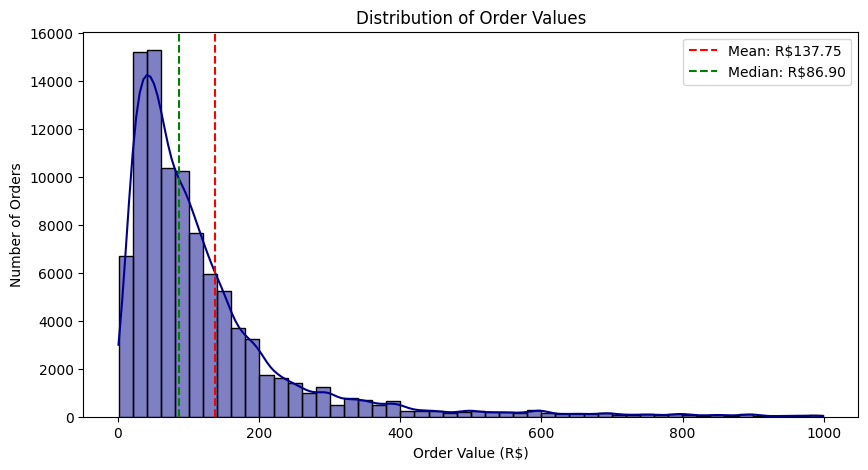

In [17]:
# Order Value Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Only remove the highest 1% from the chart for clearer visualisation
plot_data = order_totals[
    order_totals <= order_totals.quantile(0.99)
]

plt.figure(figsize=(10, 5))

sns.histplot(
    plot_data,
    bins=50,
    kde=True,
    color='darkblue'
)

# Add mean and median lines
plt.axvline(
    AOV,
    color='red',
    linestyle='--',
    label=f'Mean: R${AOV:.2f}'
)

plt.axvline(
    AOV_median,
    color='green',
    linestyle='--',
    label=f'Median: R${AOV_median:.2f}'
)

plt.title('Distribution of Order Values')
plt.xlabel('Order Value (R$)')
plt.ylabel('Number of Orders')
plt.legend()
plt.show()

The distribution of order values is right-skewed. Most orders are concentrated at lower values, while a small number of expensive orders form a long tail on the right. The mean AOV of R\$137.75 is higher than the median of R$86.90 because these expensive orders increase the average. The maximum order value is R\$13,440.00, which is much higher than most orders. Showing the full range would make the common order values difficult to see, so the chart focuses on the main part of the distribution. However, all orders were still included in the AOV calculation.


### 4.3 Customer Repeat Rate


In [18]:
# Repeat rate: customers who placed more than 1 order
# Note: customer_id is per-order, customer_unique_id is the true customer identifier
customer_orders = olist['orders'].merge(
    olist['customers'][['customer_id', 'customer_unique_id']],
    on='customer_id'
)
orders_per_customer = customer_orders.groupby('customer_unique_id')['order_id'].nunique()

repeat_customers = (orders_per_customer > 1).sum()
total_unique_customers = len(orders_per_customer)
repeat_rate = repeat_customers / total_unique_customers

print("CUSTOMER REPEAT RATE")
print("-" * 40)
print(f"Unique Customers:    {total_unique_customers:,}")
print(f"Repeat Customers:    {repeat_customers:,}")
print(f"Repeat Rate:         {repeat_rate:.2%}")
print(f"\nOrders per customer distribution:")
print(orders_per_customer.value_counts().sort_index().head(10))

CUSTOMER REPEAT RATE
----------------------------------------
Unique Customers:    96,096
Repeat Customers:    2,997
Repeat Rate:         3.12%

Orders per customer distribution:
order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


### 📝Customer Repeat Rate

The customer repeat rate is calculated using `olist['orders']` and `olist['customers']`. The two tables are joined using `customer_id`, while `customer_unique_id` is used to identify the actual customer. A repeat customer is defined as a customer who placed more than one different order.

There are 96,096 unique customers in total, and 2,997 of them placed more than one order. This gives a customer repeat rate of 3.12%. Most customers purchased only once, including 93,099 customers, while the highest number of orders placed by one customer was 17.

The low repeat rate shows that most customers did not return to place another order during the dataset period.


### 4.4 Delivery Performance


In [19]:
# Delivery metrics (only for delivered orders)
delivered = df[df['order_status'] == 'delivered'].copy()

# Keep only one row for each order
delivered_orders = delivered.drop_duplicates(
    subset='order_id'
).copy()

# Remove orders with missing delivery information
valid_deliveries = delivered_orders.dropna(
    subset=[
        'delivery_days',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
).copy()

# Calculate delivery performance
avg_delivery_days = valid_deliveries['delivery_days'].mean()
median_delivery_days = valid_deliveries['delivery_days'].median()
on_time_rate = valid_deliveries['is_on_time'].mean()


print("DELIVERY PERFORMANCE")
print("-" * 40)
print(f"Delivered Orders:     {delivered['order_id'].nunique():,}")
print(f"Avg Delivery Days:    {avg_delivery_days:.1f} days")
print(f"Median Delivery Days: {median_delivery_days:.1f} days")
print(f"On-Time Rate:         {on_time_rate:.1%}")

DELIVERY PERFORMANCE
----------------------------------------
Delivered Orders:     96,478
Avg Delivery Days:    12.1 days
Median Delivery Days: 10.0 days
On-Time Rate:         91.9%


### 📝Delivery Performance

The delivery performance analysis uses the combined `df`, but the calculations are carried out at the order level. Since the combined dataset is based on `olist['order_items']`, the same `order_id` may appear several times when an order contains multiple items. Therefore, `drop_duplicates('order_id')` is used to keep only one row for each order and avoid counting multi-item orders more than once.

There are 96,478 delivered orders. Eight orders have missing delivery information, so 96,470 orders are included in the delivery calculations. The average delivery time is 12.1 days, while the median is 10 days. The higher average suggests that some slower deliveries increased the overall average.

Around 91.9% of the orders arrived on or before the estimated delivery date, while about 8.1% arrived late. Most orders were delivered on time, but the late deliveries could be studied further to understand which factors may cause delivery delays.



### 4.5 Customer Satisfaction (Review Scores)


In [20]:
# Review metrics
reviews = olist['reviews']
avg_score = reviews['review_score'].mean()
score_distribution = reviews['review_score'].value_counts(normalize=True).sort_index()

# NPS proxy: % 5-star minus % 1-2 star
promoters = (reviews['review_score'] == 5).mean()
detractors = (reviews['review_score'] <= 2).mean()
nps_proxy = (promoters - detractors) * 100

print("CUSTOMER SATISFACTION")
print("-" * 40)
print(f"Average Review Score: {avg_score:.2f} / 5.0")
print(f"NPS Proxy Score:      {nps_proxy:.1f}")
print(f"\nScore Distribution:")
for score, pct in score_distribution.items():
    bar = "█" * int(pct * 30)
    print(f"  {score}★: {bar} {pct:.1%}")

CUSTOMER SATISFACTION
----------------------------------------
Average Review Score: 4.09 / 5.0
NPS Proxy Score:      43.1

Score Distribution:
  1★: ███ 11.5%
  2★:  3.2%
  3★: ██ 8.2%
  4★: █████ 19.3%
  5★: █████████████████ 57.8%


### 📝Customer Satisfaction

The customer satisfaction analysis uses `olist['reviews']` because each row represents one review submitted by a customer. The combined `df` is not used because it is based on item-level records. If a review is joined to an order containing several items, the same review score may appear more than once.

There are 99,224 review records, and the average review score is 4.09 out of 5. Five-star reviews make up 57.8% of all reviews, followed by four-star reviews at 19.3%. Together, four- and five-star reviews account for about 77.1% of the total, showing that most customers gave positive ratings.

However, 14.7% of the reviews received only one or two stars. A review-based proxy score of 43.1 was calculated by subtracting the percentage of one- and two-star reviews from the percentage of five-star reviews. This is only a simple reference measure and should not be treated as an official NPS score.


### 4.6 KPI Summary Dashboard


In [21]:
# Consolidated KPI Summary
kpi_summary = pd.DataFrame({
    'KPI': ['Total Revenue', 'Total Orders', 'Unique Customers', 'AOV',
            'Repeat Rate', 'On-Time Delivery', 'Avg Review Score'],
    'Value': [f"R$ {total_revenue:,.0f}", f"{total_orders:,}", f"{total_unique_customers:,}",
              f"R$ {AOV:.2f}", f"{repeat_rate:.1%}", f"{on_time_rate:.1%}", f"{avg_score:.2f}"],
    'Benchmark': ['—', '—', '—', 'R$ 100-200', '20-30%', '>90%', '>4.0']
})

print("\n" + "=" * 60)
print("📊 SMARTCOMMERCE KPI DASHBOARD")
print("=" * 60)
print(kpi_summary.to_string(index=False))
print("=" * 60)


📊 SMARTCOMMERCE KPI DASHBOARD
             KPI         Value  Benchmark
   Total Revenue R$ 13,591,644          —
    Total Orders        98,666          —
Unique Customers        96,096          —
             AOV     R$ 137.75 R$ 100-200
     Repeat Rate          3.1%     20-30%
On-Time Delivery         91.9%       >90%
Avg Review Score          4.09       >4.0


---

## 5. Basic Visualizations

Let's create visualizations to understand the data distributions.


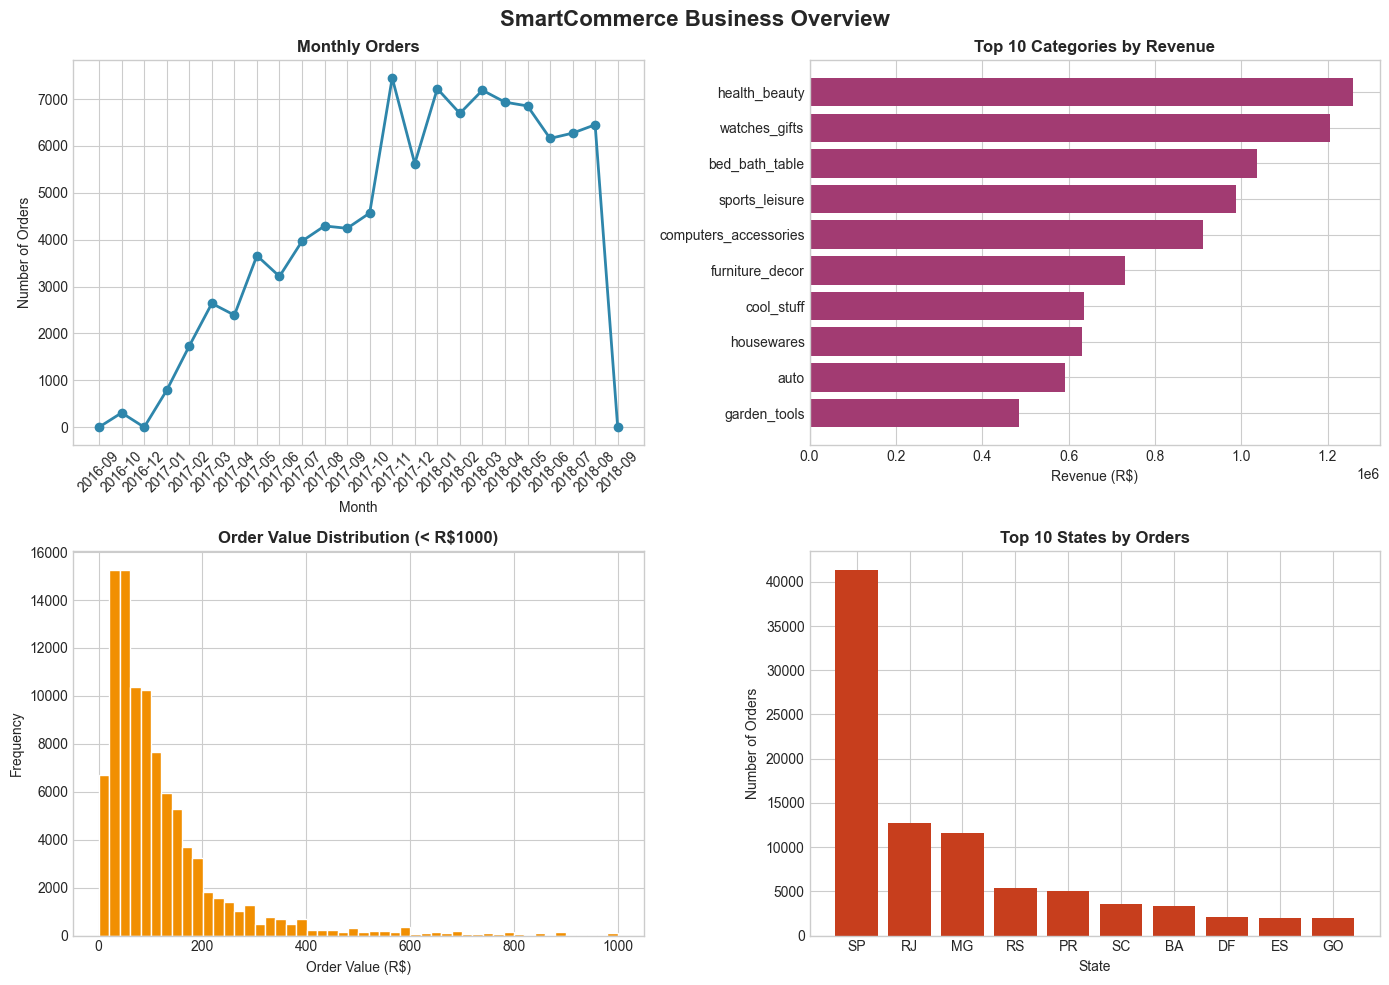

In [22]:
# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')
fig_color = '#f8f9fa'

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SmartCommerce Business Overview', fontsize=16, fontweight='bold')

# 1. Orders over time
monthly_orders = df.groupby('year_month')['order_id'].nunique()
axes[0, 0].plot(monthly_orders.index, monthly_orders.values, marker='o', linewidth=2, color='#2E86AB')
axes[0, 0].set_title('Monthly Orders', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Revenue by category (top 10)
cat_revenue = df.groupby('product_category_name_english')['price'].sum().nlargest(10)
axes[0, 1].barh(cat_revenue.index, cat_revenue.values, color='#A23B72')
axes[0, 1].set_title('Top 10 Categories by Revenue', fontweight='bold')
axes[0, 1].set_xlabel('Revenue (R$)')
axes[0, 1].invert_yaxis()

# 3. Order value distribution
order_values = df.groupby('order_id')['price'].sum()
axes[1, 0].hist(order_values[order_values < 1000], bins=50, color='#F18F01', edgecolor='white')
axes[1, 0].set_title('Order Value Distribution (< R$1000)', fontweight='bold')
axes[1, 0].set_xlabel('Order Value (R$)')
axes[1, 0].set_ylabel('Frequency')

# 4. Orders by state (top 10)
state_orders = df.groupby('customer_state')['order_id'].nunique().nlargest(10)
axes[1, 1].bar(state_orders.index, state_orders.values, color='#C73E1D')
axes[1, 1].set_title('Top 10 States by Orders', fontweight='bold')
axes[1, 1].set_xlabel('State')
axes[1, 1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

### 📝Findings from the Visualisations

1. **Monthly Orders:** The number of orders generally increased throughout 2017 and
reached its highest point in November 2017, with 7,451 orders. However, September 2016 and September 2018 contain incomplete monthly data, so they should not be compared directly with the full months.
2. **Categories by Sales Value:** health_beauty has the highest product sales value, followed by watches_gifts and bed_bath_table. These results show the total sales value of each category rather than the number of products sold.
3. **Order Value Distribution:** Most orders are concentrated at lower values, while a small number of expensive orders form a long tail on the right. Among the 98,666 orders, 97,720 have an order value below R$1,000. Therefore, the chart still shows around 99% of all orders.
4. **Orders by State:** São Paulo (SP) has the highest number of orders, with 41,375 orders. This is much higher than Rio de Janeiro (RJ) and Minas Gerais (MG), showing that customer orders are mainly concentrated in the southeastern region of Brazil.

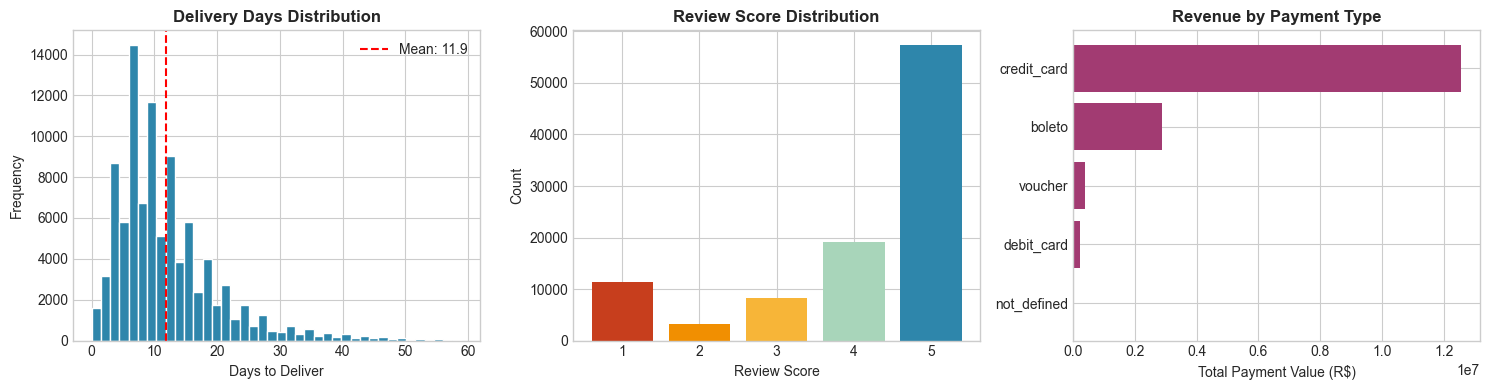

In [23]:
# Delivery and Review Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Delivery days distribution

# Use one row per order from Section 4.4
delivered_data = valid_deliveries[
    valid_deliveries['delivery_days'] < 60
]
axes[0].hist(delivered_data['delivery_days'], bins=40, color='#2E86AB', edgecolor='white')
axes[0].axvline(delivered_data['delivery_days'].mean(), color='red', linestyle='--', label=f"Mean: {delivered_data['delivery_days'].mean():.1f}")
axes[0].set_title('Delivery Days Distribution', fontweight='bold')
axes[0].set_xlabel('Days to Deliver')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Review score distribution
score_counts = olist['reviews']['review_score'].value_counts().sort_index()
colors = ['#C73E1D', '#F18F01', '#F7B538', '#A8D5BA', '#2E86AB']
axes[1].bar(score_counts.index, score_counts.values, color=colors)
axes[1].set_title('Review Score Distribution', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

# 3. Payment type distribution
payment_dist = olist['payments'].groupby('payment_type')['payment_value'].sum().sort_values(ascending=True)
axes[2].barh(payment_dist.index, payment_dist.values, color='#A23B72')
axes[2].set_title('Revenue by Payment Type', fontweight='bold')
axes[2].set_xlabel('Total Payment Value (R$)')

plt.tight_layout()
plt.show()

### 📝Delivery, Review and Payment Analysis

1. **Delivery Days Distribution:** Most delivered orders were completed within 20 days, and the delivery times are mainly concentrated around 7 to 12 days. The average delivery time shown in the chart is approximately 11.9 days. The distribution is right-skewed because a smaller number of orders took much longer to arrive. For clearer visualisation, the chart only shows orders delivered within 60 days.

2. **Review Score Distribution:** Five-star reviews are the largest group, with 57,328 reviews, followed by 19,142 four-star reviews. Together, four- and five-star ratings account for about 77.1% of all reviews, showing that most customers gave positive feedback. However, there are also 11,424 one-star reviews, suggesting that some customers had poor experiences.

3. **Payment Type Distribution:** Credit cards are the main payment method, accounting for approximately R$12.54 million, or 78.3% of the total payment value. Boleto is the second-largest payment method at around R$2.87 million, or 17.9%. Voucher and debit card payments make up only a small part of the total. This shows that Olist customers mainly relied on credit cards when making payments.


---

## 6. Save Prepared Dataset

Save the consolidated dataset for use in future labs.


In [24]:
# Save consolidated dataset for future labs (disabled for local runs)
# output_path = "smartcommerce_consolidated.csv"   # set your own path
# df.to_csv(output_path, index=False)
# print(f"Saved consolidated dataset to: {output_path}  ({df.shape[0]:,} rows x {df.shape[1]} cols)")

---

## ✅ Lab Summary

### What you finished!

1. **Data Loading**: Loaded 9 interconnected Olist tables
2. **Schema Understanding**: Identified key columns and relationships
3. **Table Merging**: Built a consolidated analysis dataset using `merge()`
4. **KPI Computation**: Calculated core e-commerce metrics:
   - Revenue & AOV
   - Repeat Rate
   - Delivery Performance
   - Customer Satisfaction


---

## 📝 Exercise (Optional)

1. Calculate the **month-over-month growth rate** for orders
2. Find the **top 5 sellers by revenue**
3. Identify which **product category has the worst delivery performance**


### Exercise 1: Month-over-Month Growth Rate for Orders

The month-over-month growth rate measures how much the number of orders increased or decreased compared with the previous month.

The formula is:

$$
\text{MoM Growth Rate}
=
\frac{\text{Current Month Orders} - \text{Previous Month Orders}}
{\text{Previous Month Orders}}
\times 100\%
$$

A positive growth rate means that the number of orders increased, while a negative growth rate means that the number of orders decreased.

Only the complete and continuous months from January 2017 to August 2018 are used. The earlier 2016 records are limited and not continuous, while September 2018 contains only a few days of data.

MONTH-OVER-MONTH ORDER GROWTH


,Number of Orders,MoM Growth Rate (%)
year_month,,
2017-01,789,NaN
2017-02,1733,119.65
2017-03,2641,52.39
2017-04,2391,-9.47
2017-05,3660,53.07
2017-06,3217,-12.10
2017-07,3969,23.38
2017-08,4293,8.16
2017-09,4243,-1.16


Highest Growth: 2017-02 (119.6%)
Largest Decline: 2017-12 (-24.5%)


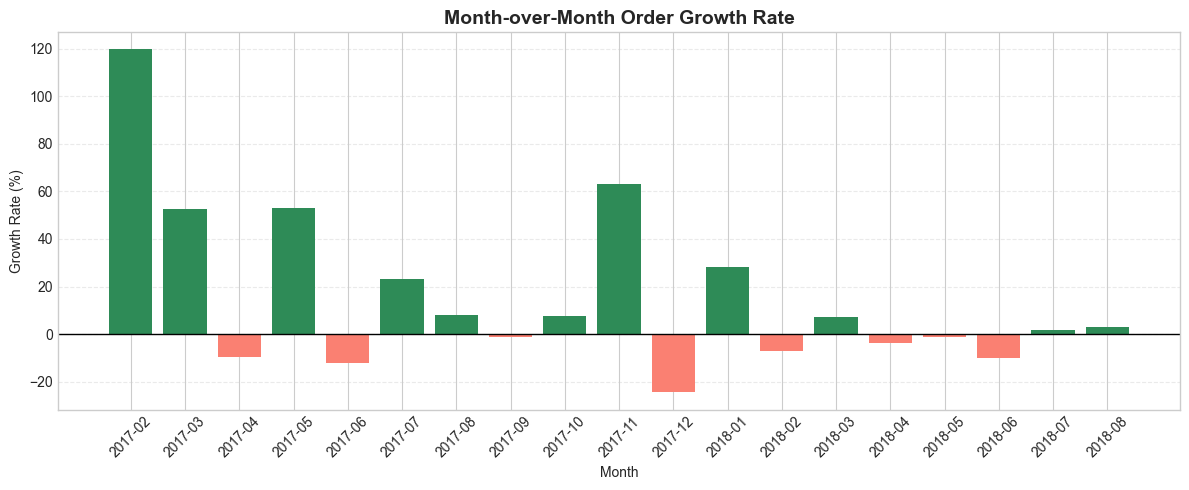

In [25]:
# ============================================================
# Exercise 1: Month-over-Month Growth Rate for Orders
# ============================================================

# Step 1: Keep one row for each order
# The combined df is item-level, so the same order_id may appear
# more than once when an order contains multiple items.

monthly_order_data = df[
    ['order_id', 'order_purchase_timestamp']
].drop_duplicates(
    subset='order_id'
).copy()


# Step 2: Keep only complete and continuous months
# 2016 has limited and discontinuous records.
# September 2018 contains only a few days of data.

monthly_order_data = monthly_order_data[
    (monthly_order_data['order_purchase_timestamp'] >= '2017-01-01') &
    (monthly_order_data['order_purchase_timestamp'] < '2018-09-01')
].copy()


# Step 3: Create a year-month column

monthly_order_data['year_month'] = (
    monthly_order_data['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)


# Step 4: Count the number of different orders in each month

monthly_orders = (
    monthly_order_data
    .groupby('year_month')['order_id']
    .nunique()
    .sort_index()
)


# Step 5: Calculate month-over-month growth rate

monthly_growth = monthly_orders.pct_change() * 100


# Step 6: Create a summary table

monthly_summary = pd.DataFrame({
    'Number of Orders': monthly_orders,
    'MoM Growth Rate (%)': monthly_growth
})

print("MONTH-OVER-MONTH ORDER GROWTH")
print("=" * 45)

display(monthly_summary.round(2))


# Step 7: Find the highest and lowest growth rates

highest_growth_month = monthly_growth.idxmax()
highest_growth_rate = monthly_growth.max()

lowest_growth_month = monthly_growth.idxmin()
lowest_growth_rate = monthly_growth.min()

print(
    f"Highest Growth: {highest_growth_month} "
    f"({highest_growth_rate:.1f}%)"
)

print(
    f"Largest Decline: {lowest_growth_month} "
    f"({lowest_growth_rate:.1f}%)"
)


# Step 8: Prepare the data for visualisation
# The first month is NaN because there is no previous month.

growth_plot = monthly_growth.dropna()


# Step 9: Use green for growth and red for decline

bar_colors = [
    'seagreen' if value >= 0 else 'salmon'
    for value in growth_plot
]


# Step 10: Create the bar chart

plt.figure(figsize=(12, 5))

plt.bar(
    growth_plot.index,
    growth_plot.values,
    color=bar_colors
)

# Add a horizontal line at 0%
plt.axhline(
    y=0,
    color='black',
    linewidth=1
)

plt.title(
    'Month-over-Month Order Growth Rate',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Month-over-Month Order Growth

The month-over-month growth rate compares the number of orders in each month with the previous month. Only the complete and continuous period from January 2017 to August 2018 is used, as the earlier 2016 records are limited and September 2018 contains only a few days of data.

The highest growth occurred in February 2017, when the number of orders increased by approximately 119.6% compared with January. However, this large percentage was partly caused by the relatively low number of orders in January. Order growth continued to move up and down during 2017 rather than increasing at a constant rate.

Another large increase occurred in November 2017, when monthly orders grew by around 63.1%. This was followed by the largest decline in December 2017, at approximately 24.5%. These changes suggest that order volume may be affected by seasonal events or promotional periods, although further analysis would be needed to confirm the reason.


### Exercise 2: Top 5 Sellers by Product Sales Value

This analysis identifies the five sellers with the highest total product sales value.

The calculation is:

$$
\text{Seller Sales Value}
=
\sum \text{Price of All Items Sold by the Seller}
$$

The `price` variable does not include freight. Therefore, the result represents product sales value rather than the total amount paid by customers.

Since each row in the combined `df` represents one item record, the prices can be summed directly by `seller_id`.


In [26]:
# ============================================================
# Exercise 2: Top 5 Sellers by Product Sales Value
# ============================================================

# Calculate sales information for each seller
seller_summary = (
    df.groupby('seller_id', as_index=False)
      .agg(
          product_sales_value=('price', 'sum'),
          number_of_orders=('order_id', 'nunique'),
          item_records_sold=('order_id', 'size')
      )
)

# Calculate each seller's percentage of total product sales
total_product_sales = df['price'].sum()

seller_summary['share_of_total_sales'] = (
    seller_summary['product_sales_value']
    / total_product_sales
    * 100
)

# Select the top 5 sellers
top_5_sellers = (
    seller_summary
    .sort_values('product_sales_value', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

# Add ranking
top_5_sellers.index = range(1, 6)
top_5_sellers.index.name = 'Rank'

# Display the results
display(
    top_5_sellers.style.format({
        'product_sales_value': 'R$ {:,.2f}',
        'number_of_orders': '{:,.0f}',
        'item_records_sold': '{:,.0f}',
        'share_of_total_sales': '{:.2f}%'
    })
)

# Combined contribution of the top 5 sellers
top_5_sales = top_5_sellers['product_sales_value'].sum()
top_5_share = top_5_sales / total_product_sales * 100

print(f"\nTop 5 Sellers' Product Sales Value: R$ {top_5_sales:,.2f}")
print(f"Top 5 Sellers' Share of Total Sales: {top_5_share:.2f}%")

,seller_id,product_sales_value,number_of_orders,item_records_sold,share_of_total_sales
Rank,,,,,
1,4869f7a5dfa277a7dca6462dcf3b52b2,"R$ 229,472.63","1,132","1,156",1.69%
2,53243585a1d6dc2643021fd1853d8905,"R$ 222,776.05",358,410,1.64%
3,4a3ca9315b744ce9f8e9374361493884,"R$ 200,472.92","1,806","1,987",1.47%
4,fa1c13f2614d7b5c4749cbc52fecda94,"R$ 194,042.03",585,586,1.43%
5,7c67e1448b00f6e969d365cea6b010ab,"R$ 187,923.89",982,"1,364",1.38%



Top 5 Sellers' Product Sales Value: R$ 1,034,687.52
Top 5 Sellers' Share of Total Sales: 7.61%


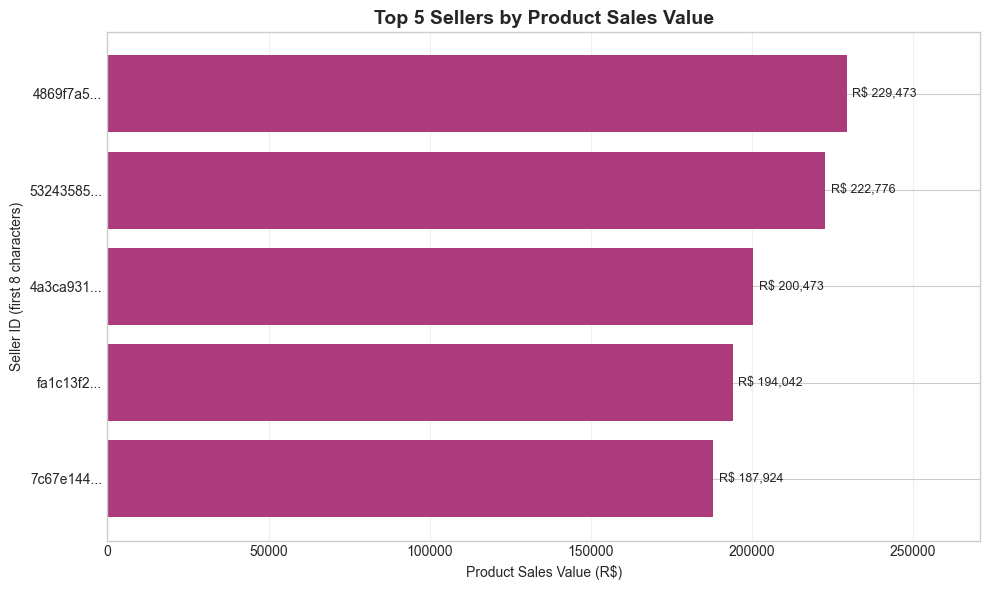

In [27]:
# Prepare data for the chart
plot_data = (
    top_5_sellers
    .sort_values('product_sales_value', ascending=True)
    .copy()
)

# Shorten seller IDs only for clearer chart labels
plot_data['seller_label'] = (
    plot_data['seller_id'].str[:8] + '...'
)

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data['seller_label'],
    plot_data['product_sales_value'],
    color='#AB3B7A'
)

# Add value labels
plt.bar_label(
    bars,
    labels=[
        f"R$ {value:,.0f}"
        for value in plot_data['product_sales_value']
    ],
    padding=4,
    fontsize=9
)

plt.title(
    'Top 5 Sellers by Product Sales Value',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Product Sales Value (R$)')
plt.ylabel('Seller ID (first 8 characters)')

# Leave space for the value labels
plt.xlim(
    0,
    plot_data['product_sales_value'].max() * 1.18
)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Top 5 Sellers by Product Sales Value

The top five sellers were identified by grouping the combined `df` by `seller_id` and adding together the `price` of all item records sold by each seller. Freight was not included, so the results represent product sales value rather than the total amount paid by customers.

The seller `4869f7a5dfa277a7dca6462dcf3b52b2` had the highest product sales value at R\$229,472.63. It was followed by `53243585a1d6dc2643021fd1853d8905` with R\$222,776.05 and `4a3ca9315b744ce9f8e9374361493884` with R$200,472.92.

Together, the top five sellers generated R$1,034,687.52, which was approximately 7.61% of the total product sales value. This suggests that the highest-selling sellers made an important contribution, but total sales were still distributed across many different sellers.

The number of orders was calculated using unique `order_id` values because one order may contain several items. However, the sales value was calculated using every item record because each item price contributes to the seller’s total sales.


### Exercise 3: Product Category with the Worst Delivery Performance

This analysis identifies the product category with the longest average delivery time.

The delivery time for each order is calculated as:

$$
\text{Delivery Days}
=
\text{Delivered Customer Date}
-
\text{Purchase Date}
$$

The average delivery time for each category is:

$$
\text{Average Delivery Days}_{c}
=
\frac{\sum \text{Delivery Days in Category }c}
{\text{Number of Delivered Orders in Category }c}
$$

The category with the highest average delivery time is considered to have the worst delivery performance.

Only categories with at least 100 delivered orders are included to avoid drawing conclusions from very small categories.


In [28]:
# ============================================================
# Exercise 3: Worst Delivery Performance by Product Category
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Minimum number of delivered orders required for comparison
MIN_ORDERS = 100

# Keep only delivered orders with a valid product category
category_delivery = df[
    (df['order_status'] == 'delivered') &
    (df['product_category_name_english'].notna())
].copy()

# Make sure the delivery columns use datetime format
date_columns = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in date_columns:
    category_delivery[column] = pd.to_datetime(
        category_delivery[column],
        errors='coerce'
    )

# Remove records with missing delivery information
category_delivery = category_delivery.dropna(
    subset=date_columns
).copy()

# Calculate the number of days taken to deliver each order
category_delivery['delivery_days'] = (
    category_delivery['order_delivered_customer_date'] -
    category_delivery['order_purchase_timestamp']
).dt.days

# Check whether the order arrived on or before the estimated date
category_delivery['is_on_time'] = (
    category_delivery['order_delivered_customer_date'] <=
    category_delivery['order_estimated_delivery_date']
)

# Keep one row for each category-order combination
category_order_delivery = category_delivery.drop_duplicates(
    subset=['product_category_name_english', 'order_id']
).copy()

# Calculate delivery performance for each category
category_summary = (
    category_order_delivery
    .groupby('product_category_name_english', as_index=False)
    .agg(
        delivered_orders=('order_id', 'nunique'),
        average_delivery_days=('delivery_days', 'mean'),
        median_delivery_days=('delivery_days', 'median'),
        on_time_rate=('is_on_time', 'mean')
    )
)

# Change on-time rate from a decimal to a percentage
category_summary['on_time_rate'] *= 100

category_summary['late_rate'] = (
    100 - category_summary['on_time_rate']
)

# Keep categories with at least 100 delivered orders
eligible_categories = category_summary[
    category_summary['delivered_orders'] >= MIN_ORDERS
].copy()

# Rank categories by average delivery days
worst_categories = (
    eligible_categories
    .sort_values('average_delivery_days', ascending=False)
    .reset_index(drop=True)
)

# Select the 10 categories with the longest delivery time
top_10_worst = worst_categories.head(10).copy()

top_10_worst.index = range(1, len(top_10_worst) + 1)
top_10_worst.index.name = 'Rank'

# Calculate overall delivery benchmarks
overall_order_delivery = category_delivery.drop_duplicates(
    subset='order_id'
)

overall_average_days = (
    overall_order_delivery['delivery_days'].mean()
)

overall_on_time_rate = (
    overall_order_delivery['is_on_time'].mean() * 100
)

# Display the results
display(
    top_10_worst.style.format({
        'delivered_orders': '{:,.0f}',
        'average_delivery_days': '{:.2f}',
        'median_delivery_days': '{:.1f}',
        'on_time_rate': '{:.1f}%',
        'late_rate': '{:.1f}%'
    })
)

# Show the category with the worst delivery performance
worst_category = worst_categories.iloc[0]

print("\nWORST DELIVERY PERFORMANCE")
print("=" * 45)
print(
    f"Product Category: "
    f"{worst_category['product_category_name_english']}"
)
print(
    f"Delivered Orders: "
    f"{worst_category['delivered_orders']:,.0f}"
)
print(
    f"Average Delivery Days: "
    f"{worst_category['average_delivery_days']:.2f} days"
)
print(
    f"Median Delivery Days: "
    f"{worst_category['median_delivery_days']:.1f} days"
)
print(
    f"On-Time Rate: "
    f"{worst_category['on_time_rate']:.1f}%"
)
print(
    f"Overall Average Delivery Time: "
    f"{overall_average_days:.1f} days"
)
print(
    f"Overall On-Time Rate: "
    f"{overall_on_time_rate:.1f}%"
)

,product_category_name_english,delivered_orders,average_delivery_days,median_delivery_days,on_time_rate,late_rate
Rank,,,,,,
1,office_furniture,"1,254",20.17,18.0,90.8%,9.2%
2,fashion_shoes,235,15.24,14.0,93.6%,6.4%
3,christmas_supplies,125,14.94,13.0,90.4%,9.6%
4,fashion_underwear_beach,117,13.56,11.0,87.2%,12.8%
5,computers,177,13.47,11.0,92.7%,7.3%
6,home_appliances_2,227,13.41,11.0,93.0%,7.0%
7,furniture_living_room,414,13.38,11.5,91.5%,8.5%
8,consoles_games,"1,018",13.29,11.0,91.8%,8.2%
9,home_confort,392,13.23,11.0,89.5%,10.5%



WORST DELIVERY PERFORMANCE
Product Category: office_furniture
Delivered Orders: 1,254
Average Delivery Days: 20.17 days
Median Delivery Days: 18.0 days
On-Time Rate: 90.8%
Overall Average Delivery Time: 12.1 days
Overall On-Time Rate: 91.9%


---
## Advanced EDA

### Product Categories with the longest average delivery time

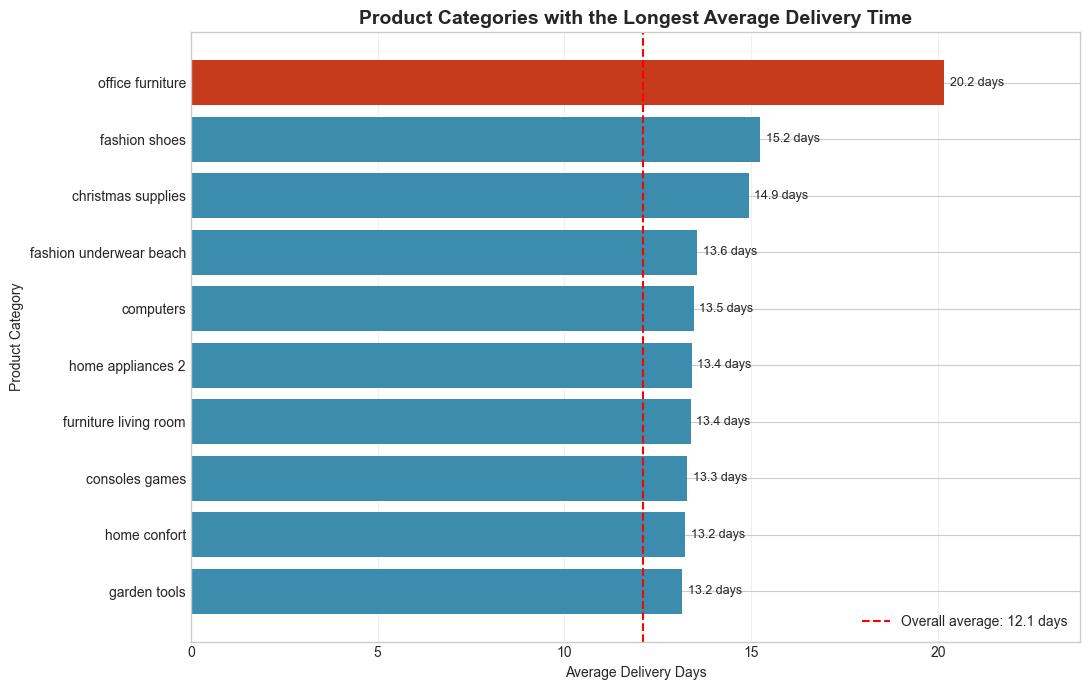

In [29]:
# Prepare the top 10 categories for visualization
plot_data = (
    top_10_worst
    .sort_values('average_delivery_days', ascending=True)
    .copy()
)

# Replace underscores to make category names easier to read
plot_data['category_label'] = (
    plot_data['product_category_name_english']
    .str.replace('_', ' ', regex=False)
)

# Highlight the category with the worst performance
worst_category_name = (
    worst_category['product_category_name_english']
)

colors = [
    '#C73B1D'
    if category == worst_category_name
    else '#3C8DAD'
    for category in plot_data[
        'product_category_name_english'
    ]
]

# Create the horizontal bar chart
plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_data['category_label'],
    plot_data['average_delivery_days'],
    color=colors
)

# Add average delivery days beside each bar
plt.bar_label(
    bars,
    labels=[
        f'{value:.1f} days'
        for value in plot_data['average_delivery_days']
    ],
    padding=4,
    fontsize=9
)

# Add the overall average as a benchmark
plt.axvline(
    overall_average_days,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Overall average: {overall_average_days:.1f} days'
)

plt.title(
    'Product Categories with the Longest Average Delivery Time',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Average Delivery Days')
plt.ylabel('Product Category')

plt.xlim(
    0,
    plot_data['average_delivery_days'].max() * 1.18
)

plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### 📝Product Category with the Worst Delivery Performance

In this analysis, the product category with the highest average delivery time is considered to have the worst delivery performance. Only delivered orders with complete delivery information were included. Categories with fewer than 100 delivered orders were excluded because results based on only a small number of orders may not be reliable.

The combined `df` was used because the product category is recorded at the item level. However, the same `order_id` may appear several times when an order contains multiple items. Therefore, duplicated category-order combinations were removed before calculating the delivery results.

Among the eligible categories, `office_furniture` had the longest average delivery time at 20.17 days. Its median delivery time was 18 days, based on 1,254 delivered orders. This was approximately 8.1 days longer than the overall average delivery time of 12.1 days.

The on-time delivery rate for `office_furniture` was approximately 90.8%, which was slightly below the overall on-time rate of 91.9%. This suggests that office furniture orders generally took much longer to reach customers, although most of them still arrived by the estimated delivery date.


### Olist Dataset Overview

In [30]:
# Create an overview of all tables in the Olist dataset

table_overview = []

for table_name, table in olist.items():
    table_overview.append({
        'Table': table_name,
        'Rows': table.shape[0],
        'Columns': table.shape[1]
    })

table_overview = pd.DataFrame(table_overview)

table_overview

,Table,Rows,Columns
0,orders,99441,8
1,order_items,112650,7
2,customers,99441,5
3,products,32951,9
4,sellers,3095,4
5,payments,103886,5
6,reviews,99224,7
7,geolocation,1000163,5
8,category_translation,71,2


**Dataset Overview**

In [31]:
# Use the existing Olist tables directly

total_orders = olist['orders']['order_id'].nunique()

unique_customers = (
    olist['customers']['customer_unique_id'].nunique()
)

total_products = olist['products']['product_id'].nunique()

total_sellers = olist['sellers']['seller_id'].nunique()

delivered_orders = (
    olist['orders']['order_status']
    .eq('delivered')
    .sum()
)

delivery_rate = delivered_orders / total_orders * 100

orders_with_items = (
    olist['order_items']['order_id'].nunique()
)

total_product_sales = (
    olist['order_items']['price'].sum()
)

total_freight = (
    olist['order_items']['freight_value'].sum()
)

print(f'Total orders: {total_orders:,}')
print(f'Unique customers: {unique_customers:,}')
print(f'Products: {total_products:,}')
print(f'Sellers: {total_sellers:,}')
print(f'Delivered orders: {delivered_orders:,}')
print(f'Delivery rate: {delivery_rate:.2f}%')
print(f'Orders with item records: {orders_with_items:,}')
print(f'Total product sales: R${total_product_sales:,.2f}')
print(f'Total freight value: R${total_freight:,.2f}')

Total orders: 99,441
Unique customers: 96,096
Products: 32,951
Sellers: 3,095
Delivered orders: 96,478
Delivery rate: 97.02%
Orders with item records: 98,666
Total product sales: R$13,591,643.70
Total freight value: R$2,251,909.54


### Order Purchase analysis

In [32]:
# Prepare the order purchase date

olist['orders']['order_purchase_timestamp'] = pd.to_datetime(
    olist['orders']['order_purchase_timestamp']
)

start_date = olist['orders']['order_purchase_timestamp'].min()
end_date = olist['orders']['order_purchase_timestamp'].max()

# Create a KPI summary table for presentation

overview_table = pd.DataFrame({
    'Indicator': [
        'Dataset Period',
        'Total Orders',
        'Unique Customers',
        'Products',
        'Sellers',
        'Delivered Orders',
        'Delivery Rate',
        'Product Sales Value',
        'Freight Value'
    ],

    'Value': [
        f'{start_date:%b %Y} – {end_date:%b %Y}',
        f'{total_orders:,}',
        f'{unique_customers:,}',
        f'{total_products:,}',
        f'{total_sellers:,}',
        f'{delivered_orders:,}',
        f'{delivery_rate:.2f}%',
        f'R${total_product_sales:,.2f}',
        f'R${total_freight:,.2f}'
    ]
})

overview_table

,Indicator,Value
0,Dataset Period,Sep 2016 – Oct 2018
1,Total Orders,"99,441"
2,Unique Customers,"96,096"
3,Products,"32,951"
4,Sellers,"3,095"
5,Delivered Orders,"96,478"
6,Delivery Rate,97.02%
7,Product Sales Value,"R$13,591,643.70"
8,Freight Value,"R$2,251,909.54"


In [33]:
display(
    overview_table.style
    .hide(axis='index')
    .set_caption('Dataset Overview')
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
)

Indicator,Value
Dataset Period,Sep 2016 – Oct 2018
Total Orders,"99,441"
Unique Customers,"96,096"
Products,"32,951"
Sellers,"3,095"
Delivered Orders,"96,478"
Delivery Rate,97.02%
Product Sales Value,"R$13,591,643.70"
Freight Value,"R$2,251,909.54"


### Main tables used in EDA

In [34]:
# Display the available table names

print(list(olist.keys()))

# Automatically identify the review table name

if 'order_reviews' in olist:
    review_table = 'order_reviews'
else:
    review_table = 'reviews'

# Main tables used in the EDA

tables_to_check = [
    'orders',
    'order_items',
    'products',
    'customers',
    review_table
]

['orders', 'order_items', 'customers', 'products', 'sellers', 'payments', 'reviews', 'geolocation', 'category_translation']


### **Missing Values Summary**

In [35]:
# Store the missing-value results

missing_results = []

# Check missing values in each selected table

for table_name in tables_to_check:

    table = olist[table_name]

    for column in table.columns:

        missing_count = table[column].isna().sum()

        # Only keep columns containing missing values

        if missing_count > 0:

            missing_rate = missing_count / len(table) * 100

            missing_results.append({
                'Table': table_name,
                'Column': column,
                'Missing Values': missing_count,
                'Missing Rate (%)': missing_rate
            })

missing_summary = pd.DataFrame(missing_results)

missing_summary = missing_summary.sort_values(
    by='Missing Rate (%)',
    ascending=False
)

display(
    missing_summary.style
    .hide(axis='index')
    .format({'Missing Rate (%)': '{:.2f}%'})
    .set_caption('Missing Values in the Main Olist Tables')
)

Table,Column,Missing Values,Missing Rate (%)
reviews,review_comment_title,87656,88.34%
reviews,review_comment_message,58247,58.70%
orders,order_delivered_customer_date,2965,2.98%
products,product_category_name,610,1.85%
products,product_name_lenght,610,1.85%
products,product_description_lenght,610,1.85%
products,product_photos_qty,610,1.85%
orders,order_delivered_carrier_date,1783,1.79%
orders,order_approved_at,160,0.16%
products,product_weight_g,2,0.01%


### **Duplicate Records**

In [36]:
# Define the key columns for each table

key_columns = {
    'orders': ['order_id'],
    'order_items': ['order_id', 'order_item_id'],
    'products': ['product_id'],
    'customers': ['customer_id'],
    review_table: ['review_id', 'order_id']
}

duplicate_results = []

for table_name in tables_to_check:

    table = olist[table_name]

    # Count completely duplicated rows

    exact_duplicates = table.duplicated().sum()

    # Count duplicated key combinations

    duplicate_keys = table.duplicated(
        subset=key_columns[table_name]
    ).sum()

    duplicate_results.append({
        'Table': table_name,
        'Exact Duplicate Rows': exact_duplicates,
        'Duplicate Key Records': duplicate_keys
    })

duplicate_summary = pd.DataFrame(duplicate_results)

display(
    duplicate_summary.style
    .hide(axis='index')
    .set_caption('Duplicate Record Check')
)

Table,Exact Duplicate Rows,Duplicate Key Records
orders,0,0
order_items,0,0
products,0,0
customers,0,0
reviews,0,0


### **Data Formats and Invalid Dates**

In [37]:
# Define date columns in each table

date_columns = {
    'orders': [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ],

    review_table: [
        'review_creation_date',
        'review_answer_timestamp'
    ]
}

date_results = []

for table_name, columns in date_columns.items():

    for column in columns:

        # Only check the column if it exists

        if column in olist[table_name].columns:

            original_missing = (
                olist[table_name][column].isna().sum()
            )

            converted_date = pd.to_datetime(
                olist[table_name][column],
                errors='coerce'
            )

            missing_after_conversion = converted_date.isna().sum()

            # Invalid values become NaT after conversion

            invalid_values = (
                missing_after_conversion - original_missing
            )

            date_results.append({
                'Table': table_name,
                'Date Column': column,
                'Original Missing Values': original_missing,
                'Invalid Date Values': invalid_values
            })

            # Save the correctly converted datetime column

            olist[table_name][column] = converted_date

date_summary = pd.DataFrame(date_results)

display(
    date_summary.style
    .hide(axis='index')
    .set_caption('Date Format and Validity Check')
)

Table,Date Column,Original Missing Values,Invalid Date Values
orders,order_purchase_timestamp,0,0
orders,order_approved_at,160,0
orders,order_delivered_carrier_date,1783,0
orders,order_delivered_customer_date,2965,0
orders,order_estimated_delivery_date,0,0
reviews,review_creation_date,0,0
reviews,review_answer_timestamp,0,0


### **Incomplete Time Periods**

In [38]:
orders = olist['orders']

# Group orders by purchase month

monthly_coverage = (
    orders
    .groupby(
        orders['order_purchase_timestamp'].dt.to_period('M')
    )
    .agg(
        Orders=('order_id', 'nunique'),
        First_Order_Date=('order_purchase_timestamp', 'min'),
        Last_Order_Date=('order_purchase_timestamp', 'max')
    )
    .reset_index()
)

monthly_coverage = monthly_coverage.rename(
    columns={'order_purchase_timestamp': 'Month'}
)

# Calculate how much of each month is covered

monthly_coverage['Observed Days'] = (
    monthly_coverage['Last_Order_Date'].dt.day
    - monthly_coverage['First_Order_Date'].dt.day
    + 1
)

monthly_coverage['Days in Month'] = (
    monthly_coverage['Month'].dt.days_in_month
)

monthly_coverage['Coverage (%)'] = (
    monthly_coverage['Observed Days']
    / monthly_coverage['Days in Month']
    * 100
)

# Display only the first and last months

boundary_months = pd.concat([
    monthly_coverage.head(1),
    monthly_coverage.tail(1)
]).drop_duplicates()

display(
    boundary_months.style
    .hide(axis='index')
    .format({'Coverage (%)': '{:.2f}%'})
    .set_caption('Coverage of the Boundary Months')
)

Month,Orders,First_Order_Date,Last_Order_Date,Observed Days,Days in Month,Coverage (%)
2016-09,4,2016-09-04 21:15:19,2016-09-15 12:16:38,12,30,40.00%
2018-10,4,2018-10-01 15:30:09,2018-10-17 17:30:18,17,31,54.84%


### **Missing Delivery Dates and Order Status**

In [39]:
# Identify whether the customer delivery date is missing

delivery_status_summary = (
    orders
    .assign(
        delivery_date_missing=
        orders['order_delivered_customer_date'].isna()
    )
    .groupby('order_status')
    .agg(
        Total_Orders=('order_id', 'nunique'),
        Missing_Delivery_Dates=(
            'delivery_date_missing',
            'sum'
        )
    )
    .reset_index()
)

# Calculate the missing rate for each order status

delivery_status_summary['Missing Rate (%)'] = (
    delivery_status_summary['Missing_Delivery_Dates']
    / delivery_status_summary['Total_Orders']
    * 100
)

delivery_status_summary = (
    delivery_status_summary
    .sort_values('Total_Orders', ascending=False)
)

display(
    delivery_status_summary.style
    .hide(axis='index')
    .format({'Missing Rate (%)': '{:.2f}%'})
    .set_caption(
        'Missing Delivery Dates by Order Status'
    )
)

order_status,Total_Orders,Missing_Delivery_Dates,Missing Rate (%)
delivered,96478,8,0.01%
shipped,1107,1107,100.00%
canceled,625,619,99.04%
unavailable,609,609,100.00%
invoiced,314,314,100.00%
processing,301,301,100.00%
created,5,5,100.00%
approved,2,2,100.00%


In [40]:
data_quality_summary = pd.DataFrame({
    'Data Quality Check': [
        'Missing review text',
        'Missing product information',
        'Missing order dates',
        'Duplicate records',
        'Invalid date values',
        'Incomplete time periods'
    ],

    'Key Finding': [
        '88.34% of review titles and 58.70% of review messages are missing',
        '610 products (1.85%) have missing category and description information',
        '160 approval dates, 1,783 carrier dates and 2,965 customer delivery dates are missing',
        'No exact duplicate rows or duplicate key records were found',
        'All date columns were converted successfully with no invalid values',
        'September 2016 and October 2018 contain only 4 orders each'
    ],

    'Treatment in EDA': [
        'Use review scores; optional review text is not required',
        'Exclude missing categories only from category-level analysis',
        'Use completed orders with valid dates for delivery analysis',
        'No duplicate removal is required',
        'Use the converted datetime columns',
        'Do not directly compare these months with complete months'
    ]
})

display(
    data_quality_summary.style
    .hide(axis='index')
    .set_caption('Data Quality Assessment of the Olist Dataset')
    .set_properties(**{
        'text-align': 'left',
        'white-space': 'normal'
    })
)

Data Quality Check,Key Finding,Treatment in EDA
Missing review text,88.34% of review titles and 58.70% of review messages are missing,Use review scores; optional review text is not required
Missing product information,610 products (1.85%) have missing category and description information,Exclude missing categories only from category-level analysis
Missing order dates,"160 approval dates, 1,783 carrier dates and 2,965 customer delivery dates are missing",Use completed orders with valid dates for delivery analysis
Duplicate records,No exact duplicate rows or duplicate key records were found,No duplicate removal is required
Invalid date values,All date columns were converted successfully with no invalid values,Use the converted datetime columns
Incomplete time periods,September 2016 and October 2018 contain only 4 orders each,Do not directly compare these months with complete months


### **Monthly Orders Visualization**

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter

orders = olist['orders'].copy()

# Ensure the purchase timestamp is in datetime format

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Extract the purchase month

orders['order_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)

# Calculate the number of unique orders in each month

monthly_orders = (
    orders
    .groupby('order_month')['order_id']
    .nunique()
    .reset_index(name='Orders')
)

# Identify the incomplete boundary months

first_month = monthly_orders['order_month'].min()
last_month = monthly_orders['order_month'].max()

# Exclude the incomplete first and last months

complete_monthly_orders = monthly_orders[
    ~monthly_orders['order_month'].isin([
        first_month,
        last_month
    ])
]

# Identify the month with the highest order volume

peak_order = complete_monthly_orders.loc[
    complete_monthly_orders['Orders'].idxmax()
]

print(
    f"Peak month: {peak_order['order_month']:%B %Y}, "
    f"{peak_order['Orders']:,.0f} orders"
)

Peak month: November 2017, 7,544 orders


Peak month: November 2017
Number of orders: 7,544


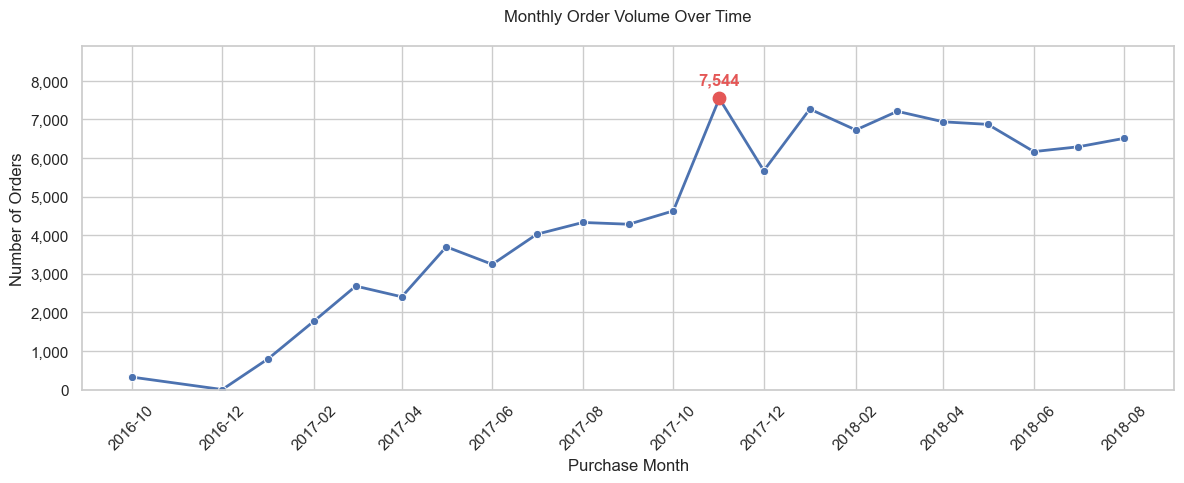

In [42]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter


# Use the order-level table

orders = olist['orders'].copy()


# Convert purchase timestamp to datetime format

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'],
    errors='coerce'
)


# Remove records without a valid purchase timestamp

orders = orders.dropna(
    subset=['order_purchase_timestamp']
)


# Extract the purchase month

orders['order_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)


# Calculate the number of unique orders in each month

monthly_orders = (
    orders
    .groupby('order_month')['order_id']
    .nunique()
    .reset_index(name='Orders')
)


# Keep only complete months
# September 2016, September 2018 and October 2018 are incomplete

complete_monthly_orders = monthly_orders[
    monthly_orders['order_month'].between(
        pd.Timestamp('2016-10-01'),
        pd.Timestamp('2018-08-01')
    )
].copy()


# Identify the month with the highest order volume

peak_order = complete_monthly_orders.loc[
    complete_monthly_orders['Orders'].idxmax()
]


# Display the peak month and order volume

print(
    f"Peak month: {peak_order['order_month']:%B %Y}"
)

print(
    f"Number of orders: {peak_order['Orders']:,.0f}"
)


# Set the visual style

sns.set_theme(style='whitegrid')


# Create the chart

fig, ax = plt.subplots(figsize=(12, 5))


sns.lineplot(
    data=complete_monthly_orders,
    x='order_month',
    y='Orders',
    marker='o',
    color='#4C72B0',
    linewidth=2,
    errorbar=None,
    ax=ax
)


# Highlight the peak month

ax.scatter(
    peak_order['order_month'],
    peak_order['Orders'],
    color='#E45756',
    s=80,
    zorder=5
)


# Add extra space above the highest point

ax.set_ylim(
    0,
    complete_monthly_orders['Orders'].max() * 1.18
)


# Display the peak value above the point

ax.annotate(
    f"{peak_order['Orders']:,.0f}",
    xy=(
        peak_order['order_month'],
        peak_order['Orders']
    ),
    xytext=(0, 8),
    textcoords='offset points',
    ha='center',
    va='bottom',
    color='#E45756',
    fontweight='bold'
)


# Format the x-axis

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)


# Format the y-axis numbers

ax.yaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f}')
)


# Add chart title and axis labels

ax.set_title(
    'Monthly Order Volume Over Time',
    pad=18
)

ax.set_xlabel('Purchase Month')
ax.set_ylabel('Number of Orders')


# Rotate the month labels

plt.xticks(rotation=45)


# Adjust the chart layout

plt.tight_layout()
plt.show()

### **Product Category Sales Performance**

In [43]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


# Select the required tables

orders = olist['orders'].copy()
order_items = olist['order_items'].copy()
products = olist['products'].copy()


# Keep only successfully delivered orders

delivered_orders = orders.loc[
    orders['order_status'] == 'delivered',
    ['order_id']
]


# Merge delivered orders with order items
# One order may contain multiple order items

category_data = delivered_orders.merge(
    order_items,
    on='order_id',
    how='inner',
    validate='one_to_many'
)


# Add product category information

category_data = category_data.merge(
    products,
    on='product_id',
    how='left',
    validate='many_to_one'
)


# Check whether the English category name already exists

if 'product_category_name_english' in category_data.columns:

    category_column = 'product_category_name_english'

else:

    # Find the category translation table automatically

    translation_tables = [
        table_name
        for table_name in olist.keys()
        if 'translation' in table_name
    ]

    if len(translation_tables) > 0:

        translation_table = olist[
            translation_tables[0]
        ]

        category_data = category_data.merge(
            translation_table,
            on='product_category_name',
            how='left',
            validate='many_to_one'
        )

        category_column = (
            'product_category_name_english'
        )

    else:

        # Use the original category name if no translation table exists

        category_column = 'product_category_name'


# Replace missing category names

category_data[category_column] = (
    category_data[category_column]
    .fillna('unknown')
)


# Calculate sales value and order volume by category

category_sales = (
    category_data
    .groupby(category_column)
    .agg(
        Sales_Value=('price', 'sum'),
        Number_of_Orders=('order_id', 'nunique')
    )
    .reset_index()
)


# Rename and format category names

category_sales = category_sales.rename(
    columns={category_column: 'Product Category'}
)

category_sales['Product Category'] = (
    category_sales['Product Category']
    .str.replace('_', ' ', regex=False)
    .str.title()
)


# Sort categories by sales value

category_sales = category_sales.sort_values(
    by='Sales_Value',
    ascending=False
)


# Select the top 10 categories

top_10_categories = category_sales.head(10).copy()


# Calculate the share contributed by the top three categories

top_3_sales = (
    category_sales
    .head(3)['Sales_Value']
    .sum()
)

total_sales = category_sales['Sales_Value'].sum()

top_3_share = top_3_sales / total_sales * 100


# Display the results

print(f'Top three category share: {top_3_share:.2f}%')

display(
    top_10_categories.style
    .hide(axis='index')
    .format({
        'Sales_Value': 'R${:,.2f}',
        'Number_of_Orders': '{:,.0f}'
    })
    .set_caption(
        'Top 10 Product Categories by Sales Value'
    )
)

Top three category share: 25.89%


Product Category,Sales_Value,Number_of_Orders
Health Beauty,"R$1,233,131.72","8,647"
Watches Gifts,"R$1,166,176.98","5,495"
Bed Bath Table,"R$1,023,434.76","9,272"
Sports Leisure,"R$954,852.55","7,530"
Computers Accessories,"R$888,724.61","6,530"
Furniture Decor,"R$711,927.69","6,307"
Housewares,"R$615,628.69","5,743"
Cool Stuff,"R$610,204.10","3,559"
Auto,"R$578,966.65","3,810"
Toys,"R$471,286.48","3,804"


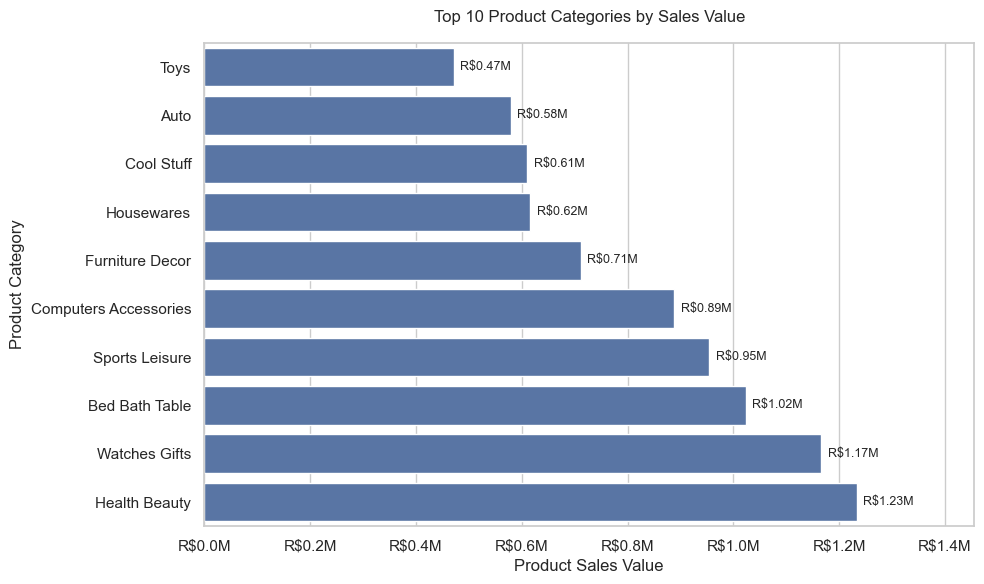

In [44]:
# Sort in ascending order for the horizontal chart

top_10_plot = top_10_categories.sort_values(
    by='Sales_Value',
    ascending=True
)


sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))


sns.barplot(
    data=top_10_plot,
    x='Sales_Value',
    y='Product Category',
    color='#4C72B0',
    ax=ax
)


# Add sales values beside the bars

maximum_sales = top_10_plot['Sales_Value'].max()

for bar, value in zip(
    ax.patches,
    top_10_plot['Sales_Value']
):

    ax.text(
        value + maximum_sales * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'R${value / 1_000_000:.2f}M',
        va='center',
        fontsize=9
    )


# Add space for the value labels

ax.set_xlim(
    0,
    maximum_sales * 1.18
)


# Format the x-axis as millions of Brazilian reais

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f'R${value / 1_000_000:.1f}M'
    )
)


ax.set_title(
    'Top 10 Product Categories by Sales Value',
    pad=15
)

ax.set_xlabel('Product Sales Value')
ax.set_ylabel('Product Category')

plt.tight_layout()
plt.show()

### **Geographic Market Concentration**

In [45]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter


# Select the required columns

orders = olist['orders'].copy()
customers = olist['customers'].copy()


# Merge orders with customer location
# Each order is matched with one customer record

state_order_data = orders[
    ['order_id', 'customer_id']
].merge(
    customers[
        ['customer_id', 'customer_state']
    ],
    on='customer_id',
    how='left',
    validate='many_to_one'
)


# Calculate order volume by state

state_summary = (
    state_order_data
    .groupby('customer_state')
    .agg(
        Number_of_Orders=('order_id', 'nunique')
    )
    .reset_index()
)


# Calculate each state's share of total orders

total_state_orders = (
    state_summary['Number_of_Orders'].sum()
)

state_summary['Order_Share'] = (
    state_summary['Number_of_Orders']
    / total_state_orders
    * 100
)


# Sort states from highest to lowest

state_summary = state_summary.sort_values(
    by='Number_of_Orders',
    ascending=False
)


# Select the top 10 states

top_10_states = state_summary.head(10).copy()


# Calculate the combined share of the top three states

top_3_state_share = (
    state_summary
    .head(3)['Order_Share']
    .sum()
)


# Display the results

print(
    f'Top three states account for '
    f'{top_3_state_share:.2f}% of all orders'
)

display(
    top_10_states.style
    .hide(axis='index')
    .format({
        'Number_of_Orders': '{:,.0f}',
        'Order_Share': '{:.2f}%'
    })
    .set_caption(
        'Top 10 States by Order Volume'
    )
)

Top three states account for 66.61% of all orders


customer_state,Number_of_Orders,Order_Share
SP,"41,746",41.98%
RJ,"12,852",12.92%
MG,"11,635",11.70%
RS,"5,466",5.50%
PR,"5,045",5.07%
SC,"3,637",3.66%
BA,"3,380",3.40%
DF,"2,140",2.15%
ES,"2,033",2.04%
GO,"2,020",2.03%


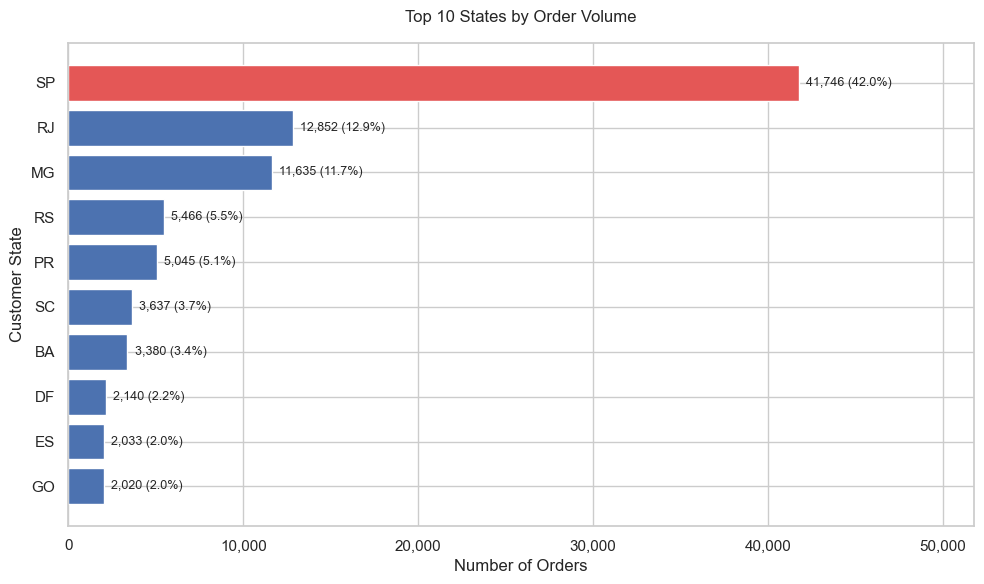

In [46]:
# Sort in ascending order for a horizontal bar chart

top_10_plot = top_10_states.sort_values(
    by='Number_of_Orders',
    ascending=True
)


# Highlight São Paulo

bar_colours = [
    '#E45756' if state == 'SP'
    else '#4C72B0'
    for state in top_10_plot['customer_state']
]


sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))


bars = ax.barh(
    top_10_plot['customer_state'],
    top_10_plot['Number_of_Orders'],
    color=bar_colours
)


# Add order volume and percentage beside each bar

for bar, share in zip(
    bars,
    top_10_plot['Order_Share']
):

    order_count = bar.get_width()

    ax.text(
        order_count
        + top_10_plot['Number_of_Orders'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{order_count:,.0f} ({share:.1f}%)',
        va='center',
        fontsize=9
    )


# Add space for the labels

ax.set_xlim(
    0,
    top_10_plot['Number_of_Orders'].max() * 1.24
)


# Format the x-axis

ax.xaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f}')
)


# Add title and labels

ax.set_title(
    'Top 10 States by Order Volume',
    pad=15
)

ax.set_xlabel('Number of Orders')
ax.set_ylabel('Customer State')


plt.tight_layout()
plt.show()

### **Order Value Distribution**

In [47]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


# Use the item-level table

order_items = olist['order_items'].copy()


# Aggregate item prices to the order level

order_values = (
    order_items
    .groupby('order_id')
    .agg(
        Order_Value=('price', 'sum')
    )
    .reset_index()
)


# Calculate descriptive statistics

total_orders = order_values['order_id'].nunique()

average_order_value = (
    order_values['Order_Value'].mean()
)

median_order_value = (
    order_values['Order_Value'].median()
)

maximum_order_value = (
    order_values['Order_Value'].max()
)


# Count orders below or equal to R$1,000

orders_below_1000 = (
    order_values['Order_Value']
    .le(1000)
    .sum()
)

coverage_below_1000 = (
    orders_below_1000
    / total_orders
    * 100
)


# Display the results

print(f'Total orders: {total_orders:,}')

print(
    f'Average order value: '
    f'R${average_order_value:,.2f}'
)

print(
    f'Median order value: '
    f'R${median_order_value:,.2f}'
)

print(
    f'Maximum order value: '
    f'R${maximum_order_value:,.2f}'
)

print(
    f'Orders at or below R$1,000: '
    f'{orders_below_1000:,}'
)

print(
    f'Percentage displayed in chart: '
    f'{coverage_below_1000:.2f}%'
)

Total orders: 98,666
Average order value: R$137.75
Median order value: R$86.90
Maximum order value: R$13,440.00
Orders at or below R$1,000: 97,723
Percentage displayed in chart: 99.04%


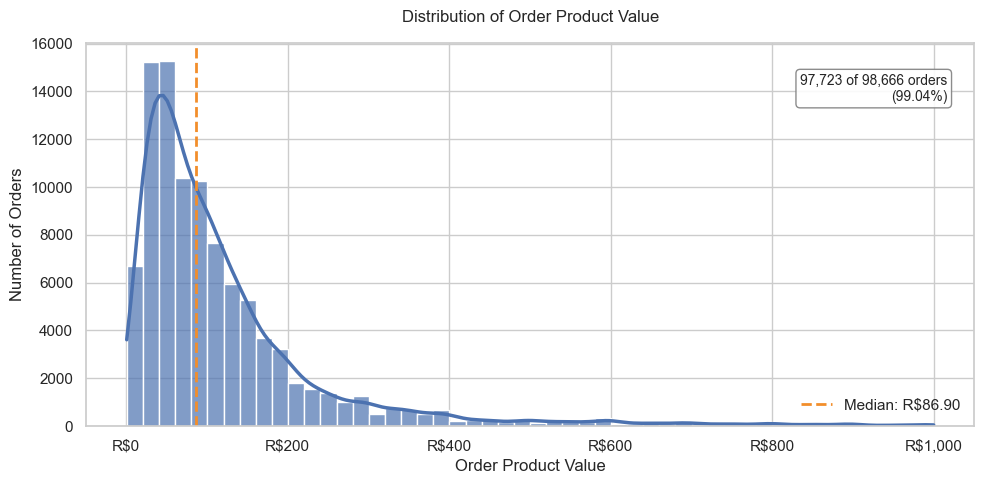

In [48]:
# Keep orders at or below R$1,000 for readability

order_value_plot = order_values[
    order_values['Order_Value'] <= 1000
].copy()


sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(10, 5))


# Plot the histogram with a KDE curve

sns.histplot(
    data=order_value_plot,
    x='Order_Value',
    bins=50,
    stat='count',
    color='#4C72B0',
    edgecolor='white',
    alpha=0.70,
    kde=True,
    kde_kws={
        'bw_adjust': 1.2
    },
    line_kws={
        'color': '#E45756',
        'linewidth': 2.5
    },
    ax=ax
)


# Mark the median order value

ax.axvline(
    median_order_value,
    color='#F28E2B',
    linestyle='--',
    linewidth=2,
    label=(
        f'Median: '
        f'R${median_order_value:,.2f}'
    )
)


# Show how much of the dataset is displayed

ax.text(
    0.97,
    0.92,
    (
        f'{orders_below_1000:,} of '
        f'{total_orders:,} orders\n'
        f'({coverage_below_1000:.2f}%)'
    ),
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox={
        'boxstyle': 'round',
        'facecolor': 'white',
        'edgecolor': 'grey',
        'alpha': 0.9
    }
)


# Format the x-axis

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f'R${value:,.0f}'
    )
)


# Add title and labels

ax.set_title(
    'Distribution of Order Product Value',
    pad=15
)

ax.set_xlabel('Order Product Value')
ax.set_ylabel('Number of Orders')

ax.legend()

plt.tight_layout()
plt.show()

### Orders by Day of Week

day_of_week
Friday       14002
Monday       16068
Saturday     10813
Sunday       11888
Thursday     14639
Tuesday      15831
Wednesday    15425
Name: order_id, dtype: int64


<Axes: title={'center': 'Orders by Day of Week'}, xlabel='Day of Week', ylabel='Number of Orders'>

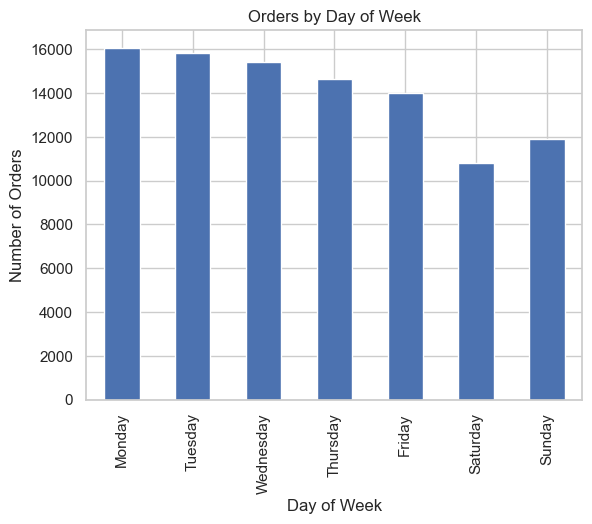

In [49]:
# analyze temporal patterns of orders placed

# analyze number of orders versus day of the week (intraweek pattern)
orders_by_day_of_week = df.groupby('day_of_week')['order_id'].nunique()
print(orders_by_day_of_week)
# plot orders vs day of week in ordinal manner
plot_orders_by_day_of_week = orders_by_day_of_week.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
# include plot title and x-axis and y-axis
plot_orders_by_day_of_week.plot(kind='bar', title='Orders by Day of Week', xlabel='Day of Week', ylabel='Number of Orders')

The analysis of orders by day of the week reveals the following patterns:

Most Orders: Monday has the highest number of orders with 16,068, closely followed by Tuesday (15,831) and Wednesday (15,425).
Least Orders: Saturday has the fewest orders with 10,813, and Sunday is also relatively low with 11,888 orders.
This suggests that customers tend to place more orders during the weekdays, with a noticeable drop in activity over the weekend.

### Compare Delivery Performance: Top 5 vs. Bottom 5 Customer States

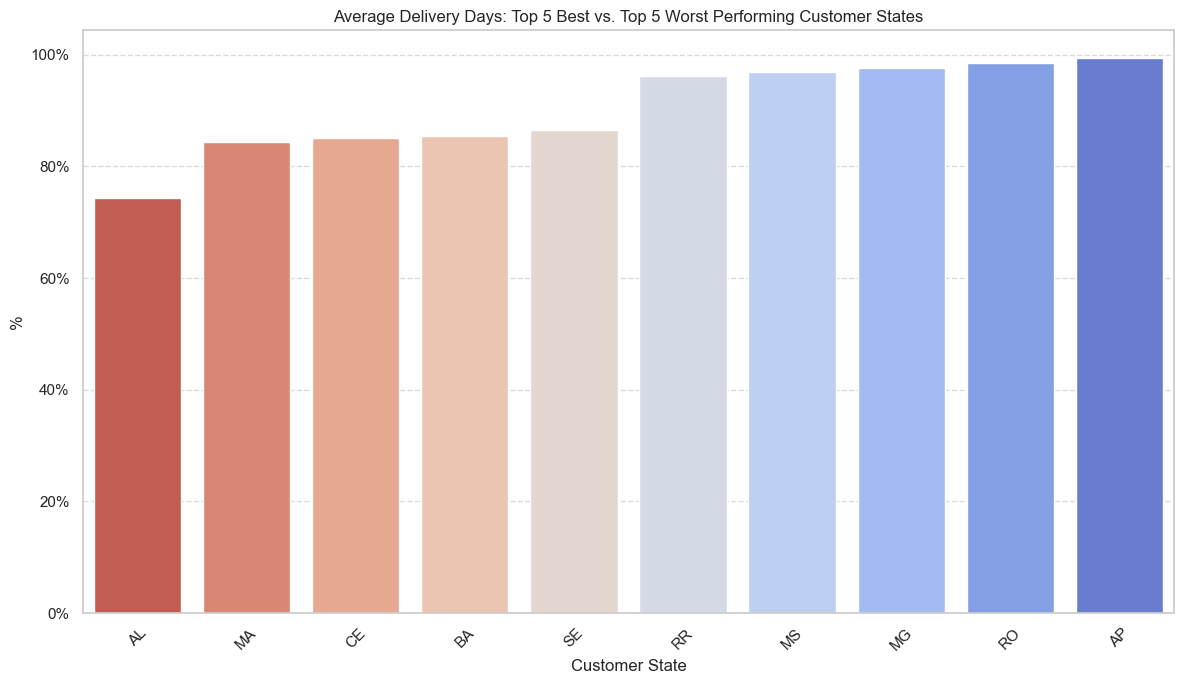

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Calculate average delivery days per customer state

# Filter for delivered orders to calculate delivery performance
delivered_orders = df[df['order_status'] == 'delivered'].copy()

# Ensure only unique orders are factored in
delivered_orders = delivered_orders.drop_duplicates(subset=['order_id'])

# calculate delivery performance based on on-time delivery between customer and seller locations
delivery_performance = delivered_orders.groupby(['customer_state', 'seller_state'])['is_on_time'].mean()

# Identify top 5 best performing states for customers (highest on-time delivery %)
top_5_best_states = delivery_performance.groupby('customer_state').mean().nlargest(5)

# Identify bottom 5 worst performing states (lowest on-time delivery %)
top_5_worst_states = delivery_performance.groupby('customer_state').mean().nsmallest(5)

# Combine for plotting
comparison_states = pd.concat([top_5_best_states, top_5_worst_states])

# Sort for better visualization
comparison_states = comparison_states.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=comparison_states.index, y=comparison_states.values, palette='coolwarm_r', ax=ax)
plt.title('Average Delivery Days: Top 5 Best vs. Top 5 Worst Performing Customer States')
plt.xlabel('Customer State')
plt.ylabel('%')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Worst Performing States: Alagoas (AL) has the lowest on-time delivery rate at 74%, followed by Maranhão (MA) at 84%, Ceará (CE) at 85%, Bahia (BA) at 85%, and Sergipe (SE) at 86%. These states show a significant proportion of late deliveries.

Best Performing States: Amapá (AP) exhibits the highest on-time delivery rate at 99%, closely followed by Rondônia (RO) and Minas Gerais (MG) both at 98%, Mato Grosso do Sul (MS) at 97%, and Roraima (RR) at 96%. These states demonstrate excellent delivery efficiency.

Significant Disparity: There's a substantial difference of approximately 25 percentage points between the worst (AL: 74%) and best (AP: 99%) performing states, indicating that delivery performance varies considerably across different customer locations. This suggests potential regional logistics challenges or operational efficiencies.

### Proportion of 'Canceled' Orders by State

Top 10 States by Order Cancellation Rate:


customer_state
RR    0.022
PI    0.006
SP    0.006
MA    0.005
RJ    0.005
GO    0.004
BA    0.004
MG    0.004
RO    0.004
SC    0.004
Name: order_id, dtype: object

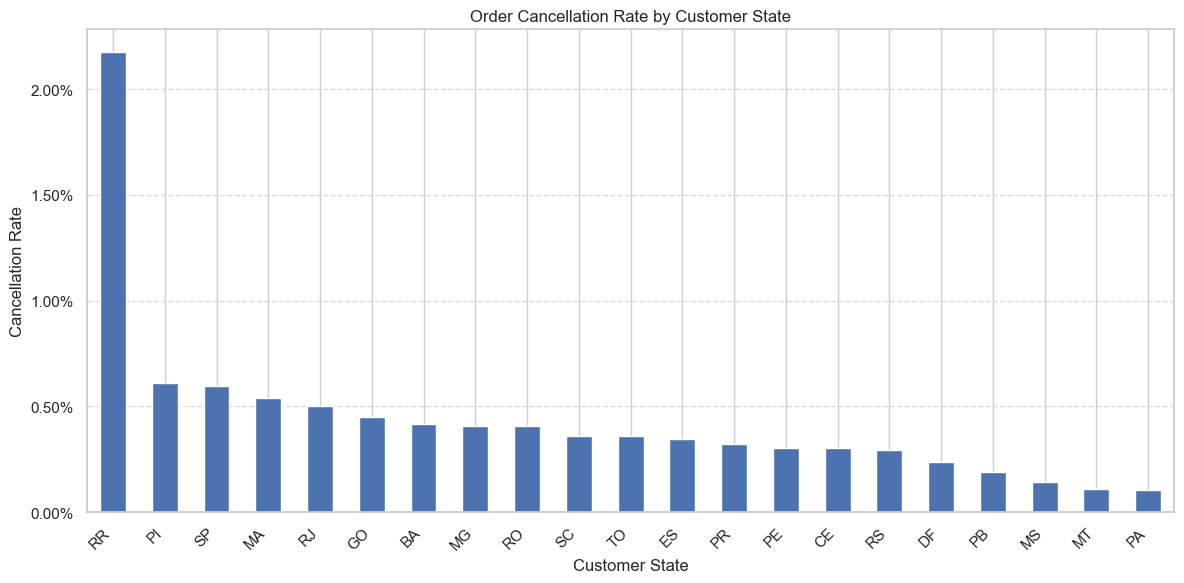

In [51]:
import matplotlib.ticker as mticker

# Calculate total orders per state
total_orders_by_state = df.groupby('customer_state')['order_id'].nunique()

# Filter for canceled orders
canceled_orders = df[df['order_status'] == 'canceled']

# Calculate canceled orders per state
canceled_orders_by_state = canceled_orders.groupby('customer_state')['order_id'].nunique()

# Calculate the proportion of canceled orders per state
cancellation_rate_by_state = (canceled_orders_by_state / total_orders_by_state).fillna(0)

# Sort and display the top 10 states by cancellation rate
print("Top 10 States by Order Cancellation Rate:")
display(cancellation_rate_by_state.nlargest(10).apply(lambda x: f'{x:.3f}'))

# Plot the cancellation rates for states with at least one cancellation
fig, ax = plt.subplots(figsize=(12, 6))
cancellation_rate_by_state[cancellation_rate_by_state > 0].sort_values(ascending=False).plot(kind='bar', ax=ax)
ax.set_title('Order Cancellation Rate by Customer State')
ax.set_xlabel('Customer State')
ax.set_ylabel('Cancellation Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0)) # Format y-axis as percentage
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Correlation Exploration

Relationships between pairs of variables — delivery timing vs. rating, geography vs. order value and on-time delivery, and review-comment length vs. rating.

### Delivery delay vs. review score

The idea of relating the rating to delivery performance *against the promised speed* (rather than raw delivery time) follows **Cui et al.** on the delivery-speed promise. The promise here is `order_estimated_delivery_date`; the variable is `actual − estimated` = `delay_days` ( > 0 = late ). *Full citation in the report.*

In [52]:
# Delivery delay vs. review score — delivered orders that have a review

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


orders  = olist['orders'].copy()
reviews = olist['reviews'].copy()


# One review score per order (a few orders carry more than one review record)

review_by_order = (
    reviews
    .groupby('order_id')['review_score']
    .mean()
    .rename('review_score')
)


# Keep only delivered orders with valid delivery dates, then inner-join reviews
# (inner join -> only delivered orders that also have a review)

dr = (
    orders.loc[
        orders['order_status'] == 'delivered',
        ['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date']
    ]
    .dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])
    .merge(review_by_order, on='order_id', how='inner')
)


# Delivery delay in calendar days: actual - estimated  ( > 0 means late )

dr['delay_days'] = (
    dr['order_delivered_customer_date'].dt.normalize()
    - dr['order_estimated_delivery_date'].dt.normalize()
).dt.days


print(f"delivered orders with a review : {len(dr):,}")
print(f"late rate (delay > 0)          : {(dr['delay_days'] > 0).mean():.2%}")
print()
print(dr['delay_days'].describe().round(1).to_string())

delivered orders with a review : 95,824
late rate (delay > 0)          : 6.66%

count   95824.00
mean      -11.90
std        10.10
min      -147.00
25%       -17.00
50%       -12.00
75%        -7.00
max       188.00


**Note on the tail.** `delay_days` runs out to **+188** and **−147**, but the extremes are **< 0.4%** of orders and partly a data artefact:

- **Very late (positive):** a handful of stuck / never-arrived orders were force-closed in a bulk clean-up — several share an `order_delivered_customer_date` of exactly `2017-09-19` or `2018-09-19`, so for those the "delivered" date is a bookkeeping entry, not a real delivery.
- **Very early (negative):** a few orders carry an `order_estimated_delivery_date` set ~5 months in the future (a bad estimate), which reads as a large negative delay.

Only ~345 orders are more than 30 days late (0.36%). The scatter below clips to ±30 days, where >99.6% of orders sit, so these outliers don't affect it.

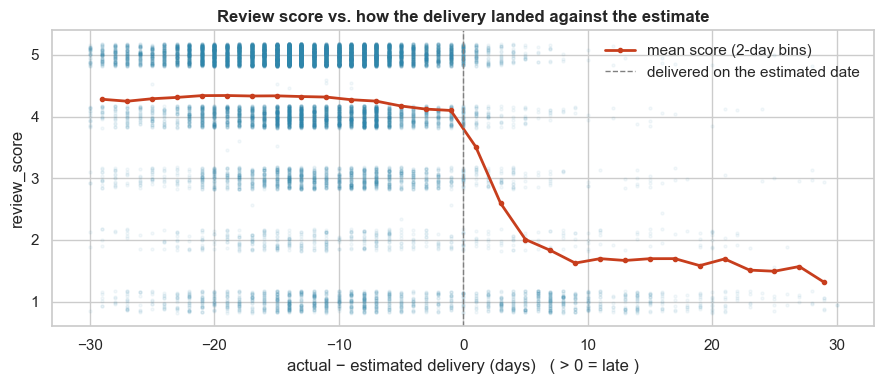

In [53]:
# Scatter: review score vs. (actual - estimated) delivery days

rng = np.random.default_rng(0)
plot = dr[dr['delay_days'].between(-30, 30)].copy()
samp = plot.sample(min(15000, len(plot)), random_state=0)
jitter = samp['review_score'] + rng.uniform(-0.18, 0.18, len(samp))   # spread the 1-5 rating so points don't overlap

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(samp['delay_days'], jitter, s=5, alpha=0.05, color='#2E86AB')

# mean review score in 2-day bins
plot['bin'] = pd.cut(plot['delay_days'], np.arange(-30, 31, 2))
binned = plot.groupby('bin', observed=True)['review_score'].mean()
ax.plot([iv.mid for iv in binned.index], binned.values,
        color='#C73E1D', lw=2, marker='o', ms=3, label='mean score (2-day bins)')

ax.axvline(0, color='grey', ls='--', lw=1, label='delivered on the estimated date')
ax.set_xlabel('actual − estimated delivery (days)   ( > 0 = late )')
ax.set_ylabel('review_score')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title('Review score vs. how the delivery landed against the estimate', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Delivery time of day vs. review score

This check follows **Kandula et al.** on delivery time-window matching — the idea that *when* in the day a parcel arrives (vs. the customer's availability) can shape satisfaction. Here the proxy is the hour of `order_delivered_customer_date`. The mean-score line below is essentially flat (`corr ≈ 0.01`), with only a slight sag for the few deliveries logged around 00:00–01:00, so **delivery time of day carries no signal for the review score** — kept as a checked-and-rejected variable. *Full citation in the report.*

delivered orders with a review    : 95,824
corr(delivery_hour, review_score) : 0.013


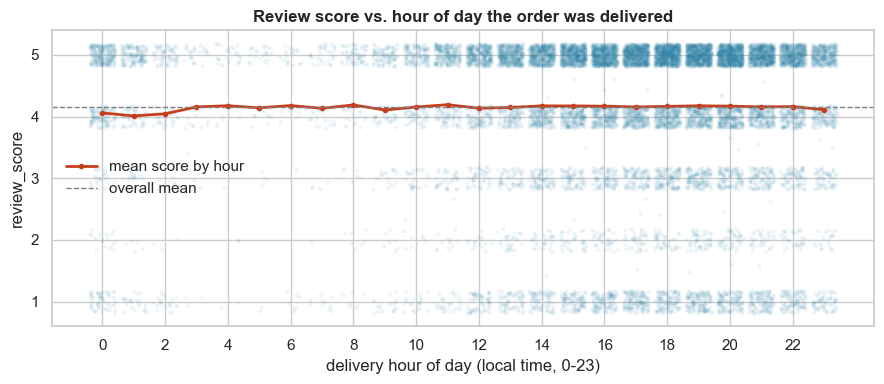

In [54]:
# Delivery hour of day vs. review score  (same population as the delay scatter above)

dr['delivery_hour'] = dr['order_delivered_customer_date'].dt.hour

print(f"delivered orders with a review    : {len(dr):,}")
print(f"corr(delivery_hour, review_score) : {dr['delivery_hour'].corr(dr['review_score']):.3f}")

rng = np.random.default_rng(0)
samp = dr.sample(min(15000, len(dr)), random_state=0)
x = samp['delivery_hour'] + rng.uniform(-0.4, 0.4, len(samp))
y = samp['review_score']   + rng.uniform(-0.18, 0.18, len(samp))

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(x, y, s=5, alpha=0.05, color='#2E86AB')

by_hour = dr.groupby('delivery_hour')['review_score'].mean()
ax.plot(by_hour.index, by_hour.values, color='#C73E1D', lw=2, marker='o', ms=3, label='mean score by hour')
ax.axhline(dr['review_score'].mean(), color='grey', ls='--', lw=1, label='overall mean')

ax.set_xlabel('delivery hour of day (local time, 0-23)')
ax.set_ylabel('review_score')
ax.set_xticks(range(0, 24, 2))
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title('Review score vs. hour of day the order was delivered', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Observation.** There is no clear relationship between delivery hour and review score. The mean rating stays around 4.1–4.2 across the whole day (`corr ≈ 0.01`); the only visible movement is a small dip for the handful of orders logged as delivered between 00:00 and 01:00, which is likely a carrier-scan / bookkeeping timestamp rather than a real late-night hand-over. Delivery time of day is therefore not a useful predictor of the rating.

### Customer state vs. order value

                 mean        sum  median     max   min
customer_state                                        
AC             173.73   15982.95   99.94 1200.00 12.90
AL             180.89   80314.81   99.94 1798.00  9.00
AM             135.50   22356.84   84.00 1688.00  8.50
AP             164.32   13474.30   99.69 1437.00 13.65
BA             134.60  511349.99   82.00 2999.89  5.20
CE             153.76  227254.71   94.20 2690.00  7.80
DF             125.77  302603.94   79.00 3999.00  4.90
ES             121.91  275037.31   78.00 6729.00  5.99
GO             126.27  294591.95   79.90 2740.00  3.90
MA             145.20  119648.22   87.28 2499.75  6.99
MG             120.75 1585308.03   77.00 4099.99  3.85
MS             142.63  116812.64   82.99 6735.00  6.10
MT             148.30  156453.53   89.70 1890.00  6.90
PA             165.69  178947.81   99.00 3980.00  4.99
PB             191.48  115268.08   99.97 4590.00  4.90
PE             145.51  262788.03   89.90 3700.00  5.99
PI        

<Axes: title={'center': 'Customer Location vs Order Value'}, xlabel='Customer Location', ylabel='Order Value'>

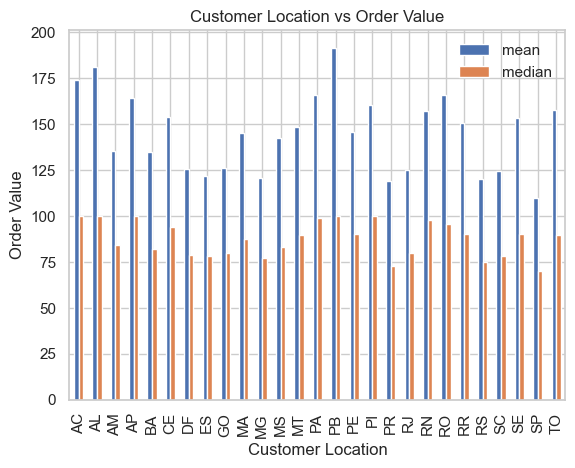

In [55]:
# Analyze if there is a correlation between geographic location of customer and value of orders (mean, sum, median, max, min)

# group customers by geographic location and value of orders (mean, sum, median, max, min)
customer_location_order_value = df.groupby(['customer_state'])['price'].agg(['mean', 'sum', 'median', 'max', 'min'])

# print output with labels
print(customer_location_order_value)

# plot a graph of custmers by geographic location and value of orders (mean and median)
customer_location_order_value.drop(columns=['sum', 'max', 'min']).plot(kind='bar', title='Customer Location vs Order Value', xlabel='Customer Location', ylabel='Order Value')


### Customer state vs. seller state — order volume

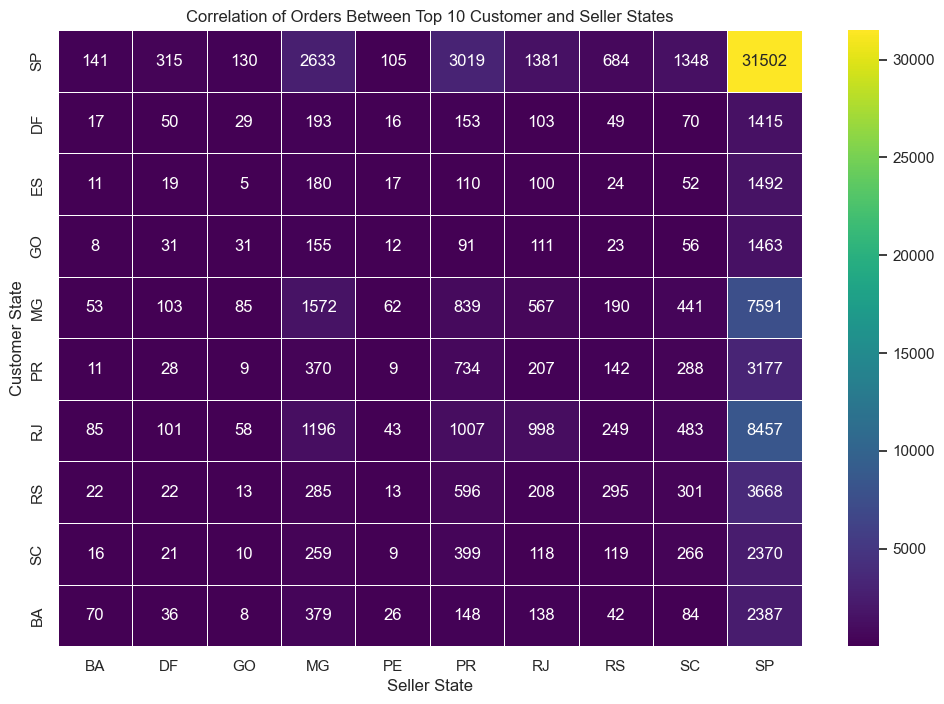

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# analyze if there is a correlation between geographic locations of customer and seller
# group customers by geographic location and sellers by geographic location
customer_location_seller_location = df.groupby(['customer_state', 'seller_state'])['order_id'].nunique()

# To visualize the correlation between two categorical variables (customer_state and seller_state)
# a heatmap is more appropriate than a scatter plot. A scatter plot requires numerical x and y axes.

# Convert the Series to a DataFrame and unstack to create a matrix suitable for a heatmap
# We'll select the top N states to make the heatmap readable.
top_n = 10 # Number of top states to include in the heatmap

# Get top customer and seller states, then sort them alphabetically as a base
top_customer_states_base = df.groupby('customer_state')['order_id'].nunique().nlargest(top_n).index.tolist()
top_seller_states_base = df.groupby('seller_state')['order_id'].nunique().nlargest(top_n).index.tolist()

# Create a custom order for customer states (y-axis): 'BA' at bottom, 'SP' at top
# For seaborn heatmap, the index order determines the y-axis labels from top to bottom.
# To have 'BA' at the bottom (start) and 'SP' at the top (max), the reindex list should be ['SP', ..., 'BA'].
intermediate_customer_states = sorted([s for s in top_customer_states_base if s not in ['BA', 'SP']])
custom_customer_order = ['SP'] + intermediate_customer_states + ['BA']

# Create a custom order for seller states (x-axis): 'BA' at left, 'SP' at right
# For seaborn heatmap, the columns order determines the x-axis labels from left to right.
# To have 'BA' at the left (start) and 'SP' at the right (end), the reindex list should be ['BA', ..., 'SP'].
intermediate_seller_states = sorted([s for s in top_seller_states_base if s not in ['BA', 'SP']])
custom_seller_order = ['BA'] + intermediate_seller_states + ['SP']

# Filter the grouped data to include only the states in our custom orders
filtered_customer_seller_location = customer_location_seller_location[
    (customer_location_seller_location.index.get_level_values('customer_state').isin(custom_customer_order)) &
    (customer_location_seller_location.index.get_level_values('seller_state').isin(custom_seller_order))
]

# Unstack the filtered Series to get a DataFrame for the heatmap
heatmap_data = filtered_customer_seller_location.unstack(fill_value=0)

# Reindex the DataFrame to ensure both rows and columns are in the desired custom order
heatmap_data = heatmap_data.reindex(index=custom_customer_order, columns=custom_seller_order, fill_value=0)

# plot a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title(f'Correlation of Orders Between Top {top_n} Customer and Seller States')
plt.xlabel('Seller State')
plt.ylabel('Customer State')
plt.show()

Strong Intra-State Correlation: There is a very strong correlation between customers and sellers within the same state, particularly in São Paulo (SP). The largest number of orders (31,502) is observed when both the customer and seller are in SP.

Dominance of SP: SP is a dominant state for both customers and sellers, indicating it is a major hub for e-commerce activity in Brazil. This is evident from the high values in the 'SP' row (customer state) and 'SP' column (seller state).

Regional Connections: Besides intra-state connections, certain inter-state connections are also notable. For example, customers in MG, PR, and RJ frequently purchase from sellers in SP, and vice versa, suggesting regional trade relationships. Bahia (BA) also shows significant connections with SP, MG, and PR sellers.

Geographic Proximity: Generally, states that are geographically closer tend to have higher order volumes between them, as would be expected due to logistics and transportation efficiencies.

Concentrated Supply: It appears that sellers are more concentrated in a few key states (like SP, MG, PR, RJ), from which they serve customers across various other states.

### Customer state vs. seller state — on-time delivery

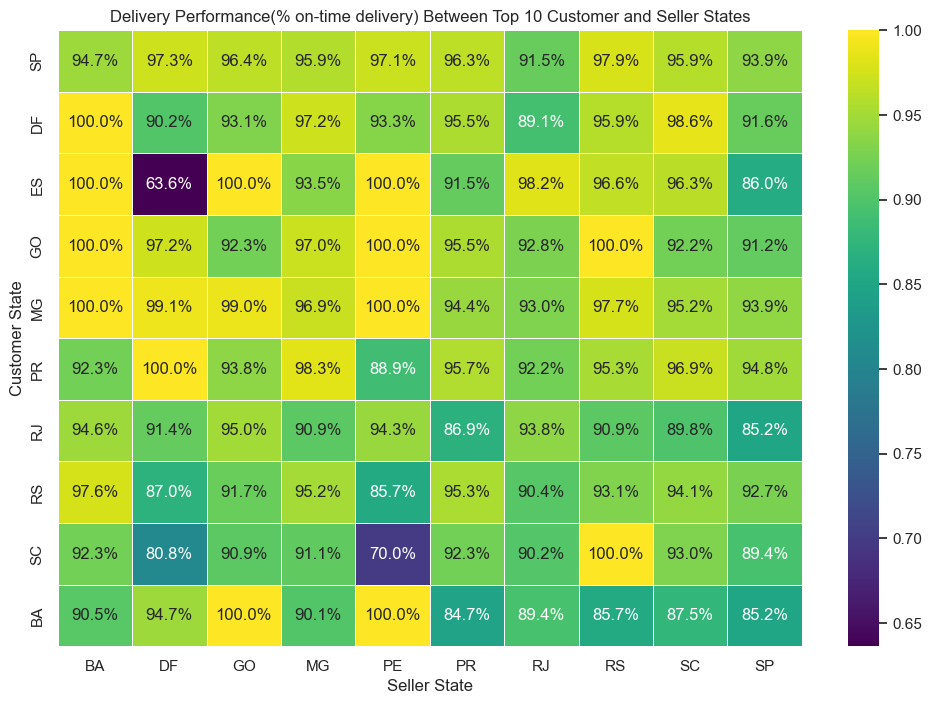

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# develop a heatmap showing the delivery performance between customer and seller locations

# Filter for delivered orders to calculate delivery performance
delivered_orders = df[df['order_status'] == 'delivered'].copy()

# calculate delivery performance based on on-time delivery between customer and seller locations
delivery_performance = delivered_orders.groupby(['customer_state', 'seller_state'])['is_on_time'].mean()

# Convert the Series to a DataFrame and unstack to create a matrix suitable for a heatmap
delivery_performance_matrix = delivery_performance.unstack(fill_value=0)

# prioritize the top ten states by order volume
top_ten_customer_states = df.groupby('customer_state')['order_id'].nunique().nlargest(10).index.tolist()
top_ten_seller_states = df.groupby('seller_state')['order_id'].nunique().nlargest(10).index.tolist()

# Create a custom order for customer states (y-axis): 'BA' at bottom, 'SP' at top
# For seaborn heatmap, the index order determines the y-axis labels from top to bottom.
# To have 'BA' at the bottom (start) and 'SP' at the top (max), the reindex list should be ['SP', ..., 'BA'].
intermediate_customer_states = sorted([s for s in top_ten_customer_states if s not in ['BA', 'SP']])
custom_customer_order = ['SP'] + intermediate_customer_states + ['BA']

# Create a custom order for seller states (x-axis): 'BA' at left, 'SP' at right
# For seaborn heatmap, the columns order determines the x-axis labels from left to right.
# To have 'BA' at the left (start) and 'SP' at the right (end), the reindex list should be ['BA', ..., 'SP'].
intermediate_seller_states = sorted([s for s in top_ten_seller_states if s not in ['BA', 'SP']])
custom_seller_order = ['BA'] + intermediate_seller_states + ['SP']

# Filter the delivery_performance_matrix to include only the top 10 customer and seller states
filtered_delivery_performance_matrix = delivery_performance_matrix.loc[top_ten_customer_states, top_ten_seller_states]

# Reindex the DataFrame to ensure both rows and columns are in the desired custom order
filtered_delivery_performance_matrix = filtered_delivery_performance_matrix.reindex(index=custom_customer_order, columns=custom_seller_order, fill_value=0)

# generate a heatmap of the delivery performance (y-axis being Customer State, x-axis being Seller State)
plt.figure(figsize=(12, 8))
sns.heatmap(filtered_delivery_performance_matrix, annot=True, fmt='.1%', cmap='viridis', linewidths=.5)
plt.title('Delivery Performance(% on-time delivery) Between Top 10 Customer and Seller States')
plt.xlabel('Seller State')
plt.ylabel('Customer State')
plt.show()

### Review-comment length vs. review score

Rows after considering unique orders and merging reviews: 98666
Number of reviews considered in this analysis: 97917
Correlation between Review Comment Message Length and Review Score: -0.38


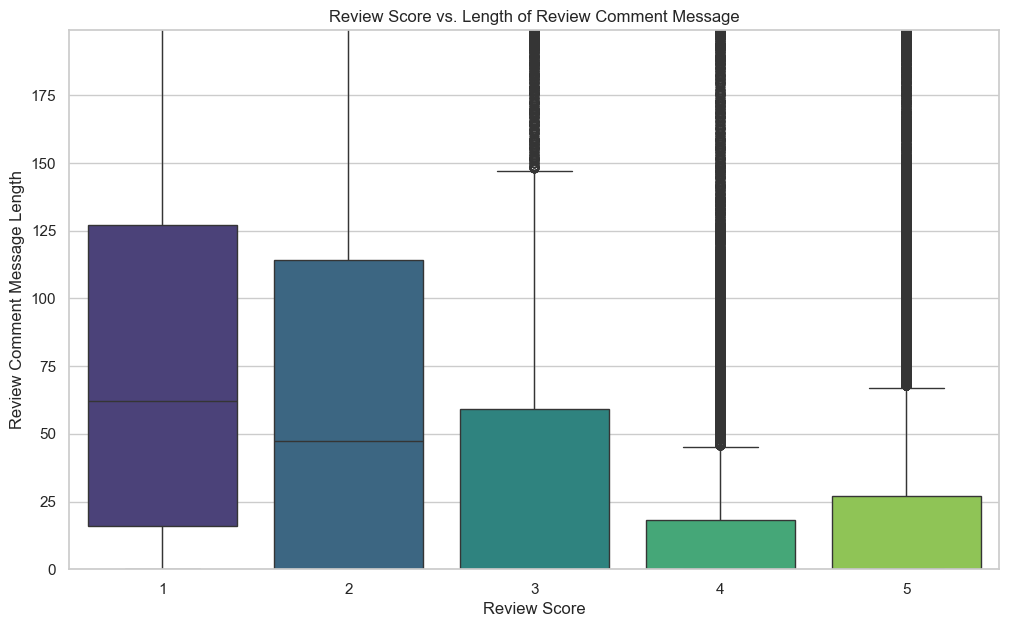

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy to avoid modifying the original DataFrame unintentionally
analysis_df = df.copy()

# only consider unique orders for analysis
analysis_df = analysis_df.drop_duplicates(subset=['order_id'])

# Aggregate review data to one entry per order_id before merging
# For review_score, taking the mean is appropriate if multiple reviews exist for an order
# For review_comment_message, we'll take the first non-null message if available
reviews_agg = olist['reviews'].groupby('order_id').agg(
    review_score=('review_score', 'mean'),
    review_comment_message=('review_comment_message', lambda x: x.dropna().iloc[0] if not x.dropna().empty else None)
).reset_index()

# Merge the aggregated review data into analysis_df
analysis_df = analysis_df.merge(reviews_agg, on='order_id', how='left')

print(f"Rows after considering unique orders and merging reviews: {len(analysis_df)}")

# Handle missing review comments by filling NaN with an empty string, then calculate length
analysis_df['review_comment_message_length'] = analysis_df['review_comment_message'].fillna('').apply(len)

# Filter out rows where review_score is NaN, as these cannot be used for correlation
analysis_df.dropna(subset=['review_score'], inplace=True)

# no. of reviews considered in this analysis
print(f"Number of reviews considered in this analysis: {len(analysis_df)}")

# Convert review_score to integer type if it's float, as it represents discrete scores
analysis_df['review_score'] = analysis_df['review_score'].astype(int)

# Calculate the correlation between review_comment_message_length and review_score
correlation_length_score = analysis_df['review_comment_message_length'].corr(analysis_df['review_score'])
print(f"Correlation between Review Comment Message Length and Review Score: {correlation_length_score:.2f}")

# Visualize the relationship using a box plot or violin plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='review_score', y='review_comment_message_length', data=analysis_df, palette='viridis')
plt.title('Review Score vs. Length of Review Comment Message')
plt.xlabel('Review Score')
plt.ylabel('Review Comment Message Length')
plt.ylim(0, analysis_df['review_comment_message_length'].quantile(0.99)) # Limit y-axis for better visibility of dense areas
plt.grid(True)
plt.show()

Based on the correlation analysis between review_comment_message_length and review_score, the following insights can be drawn:

Moderate Negative Correlation: The calculated correlation coefficient is -0.38. This indicates a moderate negative relationship between the length of a review comment message and the review score. In simpler terms, customers who write longer review comments tend to give lower review scores.

Interpretation of the Box Plot: The box plot further illustrates this trend. You would observe that lower review scores (e.g., 1-star or 2-star) are associated with a greater spread and often a higher median length of review comments. Conversely, higher review scores (e.g., 4-star or 5-star) tend to have shorter comment lengths and less variability.

This suggests that customers with less satisfactory experiences are more inclined to provide detailed feedback in their comments, leading to longer messages. Meanwhile, customers with positive experiences might simply provide a high score without elaborating as much.